# Analisi delle Repository relative ai Context File

Notebook per analizzare `git_history_diffs.json` con:
1. Grafico globale degli status dei context file.
2. Sezioni per ogni repository con contributor, top commit context-file e commit con più modifiche.

In [91]:
import json
from pathlib import Path
from collections import defaultdict

json_candidates = [
    Path(r"D:\Progetti\ContextWare\outputs\git_history_diffs.json"),
    Path("../../outputs/git_history_diffs.json"),
    Path("../outputs/git_history_diffs.json"),
    Path("outputs/git_history_diffs.json"),
]
json_path = next((p for p in json_candidates if p.exists()), None)
if json_path is None:
    raise FileNotFoundError("File git_history_diffs.json non trovato")

with open(json_path, "r", encoding="utf-8") as f:
    raw_data = json.load(f)

total_commits = 0
duplicates_by_repo = {}

for repo_item in raw_data:
    repo = repo_item.get("repo", "")
    commits = repo_item.get("acf_commits", [])
    total_commits += len(commits)
    seen = defaultdict(int)
    for commit in commits:
        h = commit.get("hash", "")
        seen[h] += 1
    dupes = {h: count for h, count in seen.items() if count > 1}
    if dupes:
        duplicates_by_repo[repo] = dupes

print(f"Repository totali nel JSON: {len(raw_data)}")
print(f"Commit totali: {total_commits}")
print(f"Repository con duplicati: {len(duplicates_by_repo)}")
print()

if duplicates_by_repo:
    for repo, dupes in sorted(duplicates_by_repo.items()):
        print(f"Repository: {repo} — {len(dupes)} hash duplicati")
        for h, count in dupes.items():
            print(f"  hash={h[:12]}...  occorrenze={count}")
        print()
else:
    print("Nessun commit duplicato trovato.")


Repository totali nel JSON: 12
Commit totali: 1073
Repository con duplicati: 1

Repository: CIRISAI/CIRISAgent — 1 hash duplicati
  hash=50a4e1de42a2...  occorrenze=2



### Verifico se all'interno del file json sono presenti commit duplicati


In [92]:
import json
from pathlib import Path
import re
import os
import urllib.request
import urllib.error
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

plt.style.use('seaborn-v0_8-whitegrid')

json_candidates = [
    Path(r"D:\\Progetti\\ContextWare\\data-manipulation\\outputs\\git_history_diffs.json"),
    Path("../../outputs/git_history_diffs.json"),
    Path("../outputs/git_history_diffs.json"),
    Path("outputs/git_history_diffs.json"),
]

json_path = next((p for p in json_candidates if p.exists()), None)
if json_path is None:
    raise FileNotFoundError("File git_history_diffs.json non trovato")

with json_path.open(encoding="utf-8") as f:
    raw_data = json.load(f)

rows = []
for repo_item in raw_data:
    repo = repo_item.get("repo")
    for commit in repo_item.get("acf_commits", []):
        commit_hash = commit.get("hash")
        commit_url = commit.get("url")
        for acf_file in commit.get("acf_files", []):
            rows.append({
                "repo": repo,
                "hash": commit_hash,
                "url": commit_url,
                "author": commit.get("commit_author", ""),
                "date": commit.get("commit_date", ""),
                "message": commit.get("commit_message", ""),
                "filename": acf_file.get("filename"),
                "status": acf_file.get("status"),
                "additions": acf_file.get("additions", 0),
                "deletions": acf_file.get("deletions", 0),
                "changes": acf_file.get("changes", 0),
            })

acf_df = pd.DataFrame(rows)
if acf_df.empty:
    raise ValueError("Nessun dato ACF trovato nel file JSON")

repo_history_dir = json_path.parent / "repo_history"
history_pattern = re.compile(r"^(?P<hash>[0-9a-f]{40}) \| (?P<date>[^|]+) \| (?P<author>[^|]+) \| (?P<message>.*) \| (?P<url>https?://.*)$")

history_rows = []
def read_lines_with_fallback(path: Path):
    data = path.read_bytes()
    best_text = None
    best_errors = None
    for enc in ("utf-8", "utf-8-sig", "cp1252", "latin-1"):
        try:
            text = data.decode(enc)
        except UnicodeDecodeError:
            text = data.decode(enc, errors="replace")
        errors = text.count(chr(0xFFFD))
        if best_errors is None or errors < best_errors:
            best_text = text
            best_errors = errors
            if errors == 0:
                break
    return best_text.splitlines() if best_text is not None else []

if repo_history_dir.exists():
    for txt_file in repo_history_dir.glob("*.txt"):
        repo_name = txt_file.stem.replace("__", "/")
        for line in read_lines_with_fallback(txt_file):
            line = line.strip()
            m = history_pattern.match(line)
            if m:
                item = m.groupdict()
                item["repo"] = repo_name
                history_rows.append(item)

history_df = pd.DataFrame(history_rows)
if not history_df.empty:
    history_df = history_df[["repo", "hash", "date", "author", "message", "url"]]
else:
    history_df = pd.DataFrame(columns=["repo", "hash", "date", "author", "message", "url"])

def clean_text(text):
    if pd.isna(text):
        return text
    text = str(text)
    text = text.replace(chr(0xFFFD), "")
    text = " ".join(text.split())
    return text

if not history_df.empty:
    history_df["message"] = history_df["message"].apply(clean_text)
    history_df["author"] = history_df["author"].apply(clean_text)

def load_env_files(paths):
    for path in paths:
        if not os.path.exists(path):
            continue
        with open(path, "r", encoding="utf-8") as handle:
            for raw in handle:
                line = raw.strip()
                if not line or line.startswith("#") or "=" not in line:
                    continue
                key, value = line.split("=", 1)
                key = key.strip()
                value = value.strip().strip('"').strip("'")
                if key and key not in os.environ:
                    os.environ[key] = value


def fetch_commit_info(owner, repo, sha, token):
    url = f"https://api.github.com/repos/{owner}/{repo}/commits/{sha}"
    headers = {
        "Accept": "application/vnd.github+json",
        "X-GitHub-Api-Version": "2022-11-28",
        "User-Agent": "contextware-report",
    }
    if token:
        headers["Authorization"] = f"Bearer {token}"
    req = urllib.request.Request(url, headers=headers)
    try:
        with urllib.request.urlopen(req) as resp:
            body = resp.read().decode("utf-8")
    except urllib.error.HTTPError:
        return None
    data = json.loads(body) if body else {}
    commit = data.get("commit") or {}
    author = commit.get("author") or {}
    committer = commit.get("committer") or {}
    date = author.get("date") or committer.get("date") or ""
    name = author.get("name") or committer.get("name") or ""
    message = (commit.get("message") or "").splitlines()[0]
    return {"message": message, "author": name, "date": date}


def refresh_messages_for_repo(history_df, repo_name, hashes, token_env="GITHUB_TOKEN"):
    if not hashes:
        return history_df
    load_env_files([".env", os.path.join(".contextWare", ".env")])
    token = os.environ.get(token_env)
    owner, repo = repo_name.split("/", 1)

    repo_rows = history_df[history_df["repo"] == repo_name]
    existing_messages = dict(zip(repo_rows["hash"], repo_rows["message"]))

    targets = []
    for sha in hashes:
        msg = existing_messages.get(sha)
        if msg is None:
            targets.append(sha)
            continue
        if str(msg).count("?") >= 3:
            targets.append(sha)

    if not targets:
        return history_df

    for sha in targets:
        info = fetch_commit_info(owner, repo, sha, token)
        if not info:
            continue
        message = clean_text(info.get("message"))
        author = clean_text(info.get("author"))
        date = clean_text(info.get("date"))
        mask = (history_df["repo"] == repo_name) & (history_df["hash"] == sha)
        if mask.any():
            if message:
                history_df.loc[mask, "message"] = message
            if author:
                history_df.loc[mask, "author"] = author
            if date:
                history_df.loc[mask, "date"] = date
        else:
            history_df = pd.concat(
                [
                    history_df,
                    pd.DataFrame(
                        [
                            {
                                "repo": repo_name,
                                "hash": sha,
                                "date": date,
                                "author": author,
                                "message": message,
                                "url": f"https://github.com/{repo_name}/commit/{sha}",
                            }
                        ]
                    ),
                ],
                ignore_index=True,
            )

    return history_df


# Fix mojibake in bannzai repo messages by re-fetching from GitHub.
bannzai_repo = "bannzai/SwiftTUI"
bannzai_hashes = (
    acf_df.loc[acf_df["repo"] == bannzai_repo, "hash"].dropna().unique().tolist()
)
if bannzai_hashes:
    history_df = refresh_messages_for_repo(history_df, bannzai_repo, bannzai_hashes)

commit_context_df = (
    acf_df.groupby(["repo", "hash", "url"], as_index=False)
    .agg(
        context_files=("filename", "count"),
        additions=("additions", "sum"),
        deletions=("deletions", "sum"),
        changes=("changes", "sum"),
        author=("author", "first"),
        date=("date", "first"),
        message=("message", "first"),
    )
)

for col in ("author", "date", "message"):
    commit_context_df[col] = commit_context_df[col].replace("", None).fillna("N/A")

display(Markdown(f"**Sorgente dati:** `{json_path}`"))
display(Markdown(f"**Repository analizzate:** {acf_df['repo'].nunique()}"))

**Sorgente dati:** `..\..\outputs\git_history_diffs.json`

**Repository analizzate:** 12

### Esclusione delle repository con almeno un commit in giapponese o coreano

Vengono rimosse dall'analisi tutte le repository che presentano anche un solo messaggio di commit
scritto in giapponese (hiragana/katakana) o coreano (hangul), poiché comprometterebbero
i risultati nel calcolo delle ACF.

In [93]:
import re
from collections import defaultdict

_JA_RE = re.compile(r"[぀-ゟ゠-ヿ]")
_KO_RE = re.compile(r"[가-힯ᄀ-ᇿ㄰-㆏]")

def _is_ja_or_ko(text):
    if not isinstance(text, str) or not text.strip():
        return False
    return bool(_JA_RE.search(text)) or bool(_KO_RE.search(text))

repo_ja_ko = defaultdict(int)

# Controlla acf_df (commit sul context file)
for _, row in acf_df.iterrows():
    if _is_ja_or_ko(str(row.get("message", ""))):
        repo_ja_ko[row["repo"]] += 1

# Controlla history_df solo se non è vuoto
if not history_df.empty:
    for _, row in history_df.iterrows():
        if _is_ja_or_ko(str(row.get("message", ""))):
            repo_ja_ko[row["repo"]] += 1

removed_repos = set(repo_ja_ko.keys())

print("Repository rimosse (almeno un commit in giapponese o coreano):")
if removed_repos:
    for repo in sorted(removed_repos, key=lambda r: repo_ja_ko[r], reverse=True):
        print(f"  {repo:<55} {repo_ja_ko[repo]} commit in ja/ko")
else:
    print("  Nessuna repository trovata con questa casistica.")

acf_df            = acf_df[~acf_df["repo"].isin(removed_repos)].copy()
history_df        = history_df[~history_df["repo"].isin(removed_repos)].copy()
commit_context_df = commit_context_df[~commit_context_df["repo"].isin(removed_repos)].copy()

print(f"Repository rimaste in analisi: {acf_df['repo'].nunique()}")


Repository rimosse (almeno un commit in giapponese o coreano):
  bannzai/SwiftTUI                                        47 commit in ja/ko
  baleen37/dotfiles                                       36 commit in ja/ko
Repository rimaste in analisi: 10


### Aggiornamento del file json senza le repository bannzai e baleen37

In [94]:
import json

with open(json_path, "r", encoding="utf-8") as f:
    raw_data = json.load(f)

before = len(raw_data)
raw_data_cleaned = [item for item in raw_data if item.get("repo") not in removed_repos]
after = len(raw_data_cleaned)

with open(json_path, "w", encoding="utf-8") as f:
    json.dump(raw_data_cleaned, f, ensure_ascii=False, indent=2)

print(f"Repository rimosse dal JSON: {before - after}")
print(f"Repository rimaste nel JSON: {after}")
for repo in sorted(removed_repos):
    print(f"  - {repo}")
print(f"\nFile aggiornato: {json_path}")


Repository rimosse dal JSON: 2
Repository rimaste nel JSON: 10
  - baleen37/dotfiles
  - bannzai/SwiftTUI

File aggiornato: ..\..\outputs\git_history_diffs.json


### Distribuzione globale dei commit relativi al context file

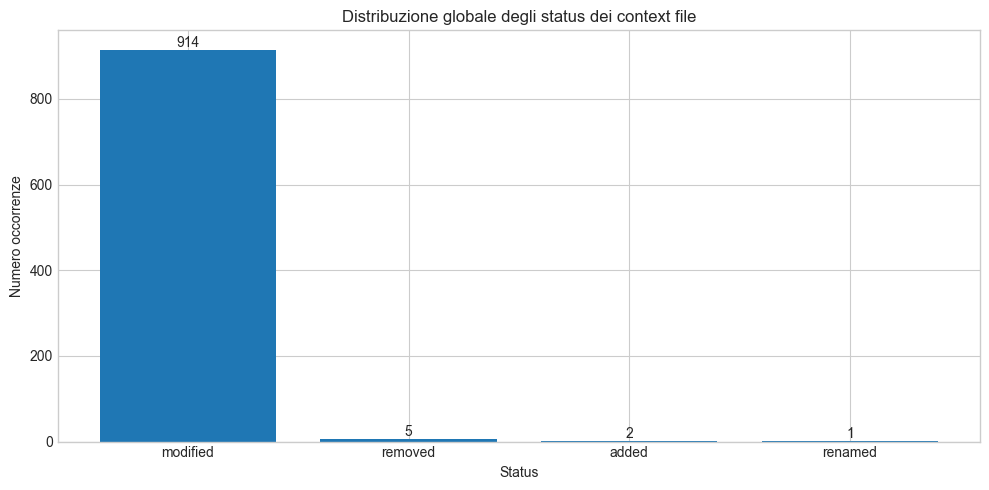

,count
status,
modified,914
removed,5
added,2
renamed,1


In [95]:
status_counts = acf_df["status"].value_counts().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(status_counts.index, status_counts.values)
ax.set_title("Distribuzione globale degli status dei context file")
ax.set_xlabel("Status")
ax.set_ylabel("Numero occorrenze")
ax.bar_label(bars)
plt.tight_layout()
plt.show()

display(status_counts.rename_axis("status").to_frame("count"))

In [96]:
def show_repo_report(repo_name: str, top_n: int = 10):
    display(Markdown(f"## {repo_name}"))

    repo_commits = commit_context_df[commit_context_df["repo"] == repo_name].copy()
    if repo_commits.empty:
        display(Markdown("Nessun commit context-file trovato."))
        return

    display(Markdown("### Contributor nella repository"))
    # Usa history_df se disponibile, altrimenti acf_df (contributor sul context file)
    if not history_df.empty:
        contributor_source = history_df[history_df["repo"] == repo_name]["author"]
        xlabel = "Numero commit nella repository"
    else:
        contributor_source = acf_df[acf_df["repo"] == repo_name]["author"]
        xlabel = "Numero commit sul context file"

    repo_contributors = (
        contributor_source
        .value_counts()
        .head(top_n)
        .sort_values(ascending=True)
    )
    if not repo_contributors.empty:
        fig, ax = plt.subplots(figsize=(10, max(3, len(repo_contributors) * 0.45)))
        bars = ax.barh(repo_contributors.index, repo_contributors.values)
        ax.set_title(f"Top contributor per commit - {repo_name}")
        ax.set_xlabel(xlabel)
        ax.set_ylabel("Contributor")
        ax.bar_label(bars)
        plt.tight_layout()
        plt.show()
    else:
        display(Markdown("Nessun contributor trovato."))

    display(Markdown("### Top commit relativi ai context file (per numero di context file toccati)"))
    top_context_commits = (
        repo_commits.sort_values(["context_files", "changes"], ascending=False)
        [["hash", "author", "date", "context_files", "additions", "deletions", "changes", "message", "url"]]
        .head(top_n)
        .reset_index(drop=True)
    )
    with pd.option_context("display.max_colwidth", None, "display.max_rows", None, "display.width", None):
        display(top_context_commits)

    display(Markdown("### Commit context-file con maggiori modifiche (additions + deletions)"))
    top_changes = (
        repo_commits.sort_values("changes", ascending=False)
        [["hash", "author", "date", "changes", "additions", "deletions", "context_files", "message", "url"]]
        .head(top_n)
        .reset_index(drop=True)
    )
    with pd.option_context("display.max_colwidth", None, "display.max_rows", None, "display.width", None):
        display(top_changes)


### Contributor all'interno della repository BMPixel/cui e commit relativi ai context file che hanno ricevuto maggiori modifiche (additions, deletions)

## BMPixel/cui

### Contributor nella repository

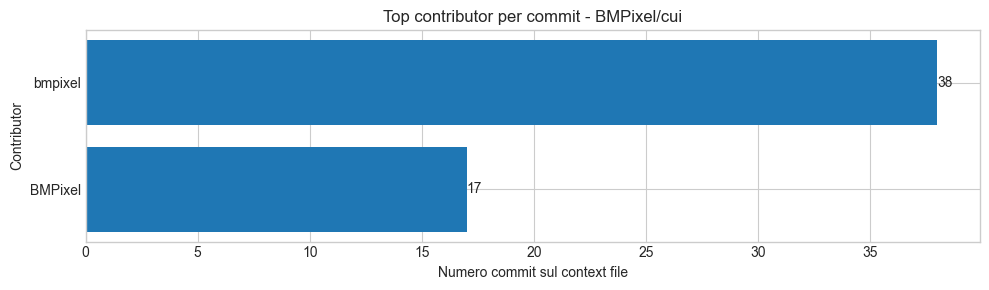

### Top commit relativi ai context file (per numero di context file toccati)

,hash,author,date,context_files,additions,deletions,changes,message,url
0,87661fbc95c7b0ae380988b63a2047e90f135458,bmpixel,2025-06-20T13:40:05Z,1,38,579,617,Add multiple CLAUDE.md,https://github.com/wbopan/cui/compare/adfc2f06667c4f89fb69001f5c32d5fcac6342b9...87661fbc95c7b0ae380988b63a2047e90f135458
1,d4009e36b9b07390f403e1f1e4f6f9433aae4de3,bmpixel,2025-06-17T12:38:50Z,1,17,569,586,"Remove MCP, continue endpoint and rewrite tests",https://github.com/wbopan/cui/compare/9a964d8e23f490c90fe92ca7b102a8b8352f51be...d4009e36b9b07390f403e1f1e4f6f9433aae4de3
2,adfc2f06667c4f89fb69001f5c32d5fcac6342b9,bmpixel,2025-06-20T13:21:22Z,1,477,49,526,Enhance API response clarity and add resume CLI command,https://github.com/wbopan/cui/compare/3a2390e038855487864e1baf0d3fc6a29072cb5e...adfc2f06667c4f89fb69001f5c32d5fcac6342b9
3,bd56bb3f8facc0ab95c79887ab5e73db930d3915,bmpixel,2025-06-12T11:47:47Z,1,503,16,519,Fix streaming integration tests with proper HTTP streaming approach,https://github.com/wbopan/cui/compare/6861081e970d14d25a9f527d114e292f8c5240d1...bd56bb3f8facc0ab95c79887ab5e73db930d3915
4,6f7ecdfff629b3515e12d50bd2860de806e710da,BMPixel,2025-07-11T07:23:40Z,1,3,283,286,Comment out auto refreshing,https://github.com/wbopan/cui/compare/9f75f31762cf71000e2995e7f41193767d1a8586...6f7ecdfff629b3515e12d50bd2860de806e710da
5,de7869736d7d8deee93f2f2b081cda999a7857e9,BMPixel,2025-07-22T03:53:15Z,1,67,160,227,Add and refine CLAUDE.md,https://github.com/wbopan/cui/compare/33a959c984894fff5ed5553dddb1134a621132e7...de7869736d7d8deee93f2f2b081cda999a7857e9
6,1eb89ca7e391d4ea65e625d824c00516d354edae,bmpixel,2025-06-18T05:55:18Z,1,163,15,178,Update unit tests and source code with comprehensive test coverage,https://github.com/wbopan/cui/compare/6e8f743d0ee5fa476c6b5bd622eb9cc6a0d60b11...1eb89ca7e391d4ea65e625d824c00516d354edae
7,a09cf067a8681c73e6ef6b07a8f995f7bc71e7ff,bmpixel,2025-08-07T03:06:29Z,1,75,98,173,tests: revert to jest tests,https://github.com/wbopan/cui/compare/68d3a6d90e6a2751007f764dbf90bde277231985...a09cf067a8681c73e6ef6b07a8f995f7bc71e7ff
8,83b64fd3517223d11ae0fc65264f9ed84d9a0be1,bmpixel,2025-06-19T01:34:46Z,1,70,0,70,Add resume conversation API endpoint,https://github.com/wbopan/cui/compare/a49989176405d659fb2c714078add15ad7d43b6a...83b64fd3517223d11ae0fc65264f9ed84d9a0be1
9,87c5a6e96954aeabaf8ac658261ac1fde417871a,bmpixel,2025-06-19T01:51:53Z,1,6,61,67,Add resume api endpoint,https://github.com/wbopan/cui/compare/83b64fd3517223d11ae0fc65264f9ed84d9a0be1...87c5a6e96954aeabaf8ac658261ac1fde417871a


### Commit context-file con maggiori modifiche (additions + deletions)

,hash,author,date,changes,additions,deletions,context_files,message,url
0,87661fbc95c7b0ae380988b63a2047e90f135458,bmpixel,2025-06-20T13:40:05Z,617,38,579,1,Add multiple CLAUDE.md,https://github.com/wbopan/cui/compare/adfc2f06667c4f89fb69001f5c32d5fcac6342b9...87661fbc95c7b0ae380988b63a2047e90f135458
1,d4009e36b9b07390f403e1f1e4f6f9433aae4de3,bmpixel,2025-06-17T12:38:50Z,586,17,569,1,"Remove MCP, continue endpoint and rewrite tests",https://github.com/wbopan/cui/compare/9a964d8e23f490c90fe92ca7b102a8b8352f51be...d4009e36b9b07390f403e1f1e4f6f9433aae4de3
2,adfc2f06667c4f89fb69001f5c32d5fcac6342b9,bmpixel,2025-06-20T13:21:22Z,526,477,49,1,Enhance API response clarity and add resume CLI command,https://github.com/wbopan/cui/compare/3a2390e038855487864e1baf0d3fc6a29072cb5e...adfc2f06667c4f89fb69001f5c32d5fcac6342b9
3,bd56bb3f8facc0ab95c79887ab5e73db930d3915,bmpixel,2025-06-12T11:47:47Z,519,503,16,1,Fix streaming integration tests with proper HTTP streaming approach,https://github.com/wbopan/cui/compare/6861081e970d14d25a9f527d114e292f8c5240d1...bd56bb3f8facc0ab95c79887ab5e73db930d3915
4,6f7ecdfff629b3515e12d50bd2860de806e710da,BMPixel,2025-07-11T07:23:40Z,286,3,283,1,Comment out auto refreshing,https://github.com/wbopan/cui/compare/9f75f31762cf71000e2995e7f41193767d1a8586...6f7ecdfff629b3515e12d50bd2860de806e710da
5,de7869736d7d8deee93f2f2b081cda999a7857e9,BMPixel,2025-07-22T03:53:15Z,227,67,160,1,Add and refine CLAUDE.md,https://github.com/wbopan/cui/compare/33a959c984894fff5ed5553dddb1134a621132e7...de7869736d7d8deee93f2f2b081cda999a7857e9
6,1eb89ca7e391d4ea65e625d824c00516d354edae,bmpixel,2025-06-18T05:55:18Z,178,163,15,1,Update unit tests and source code with comprehensive test coverage,https://github.com/wbopan/cui/compare/6e8f743d0ee5fa476c6b5bd622eb9cc6a0d60b11...1eb89ca7e391d4ea65e625d824c00516d354edae
7,a09cf067a8681c73e6ef6b07a8f995f7bc71e7ff,bmpixel,2025-08-07T03:06:29Z,173,75,98,1,tests: revert to jest tests,https://github.com/wbopan/cui/compare/68d3a6d90e6a2751007f764dbf90bde277231985...a09cf067a8681c73e6ef6b07a8f995f7bc71e7ff
8,83b64fd3517223d11ae0fc65264f9ed84d9a0be1,bmpixel,2025-06-19T01:34:46Z,70,70,0,1,Add resume conversation API endpoint,https://github.com/wbopan/cui/compare/a49989176405d659fb2c714078add15ad7d43b6a...83b64fd3517223d11ae0fc65264f9ed84d9a0be1
9,87c5a6e96954aeabaf8ac658261ac1fde417871a,bmpixel,2025-06-19T01:51:53Z,67,6,61,1,Add resume api endpoint,https://github.com/wbopan/cui/compare/83b64fd3517223d11ae0fc65264f9ed84d9a0be1...87c5a6e96954aeabaf8ac658261ac1fde417871a


In [97]:
show_repo_report("BMPixel/cui")

## CIRISAI/CIRISAgent

### Contributor nella repository

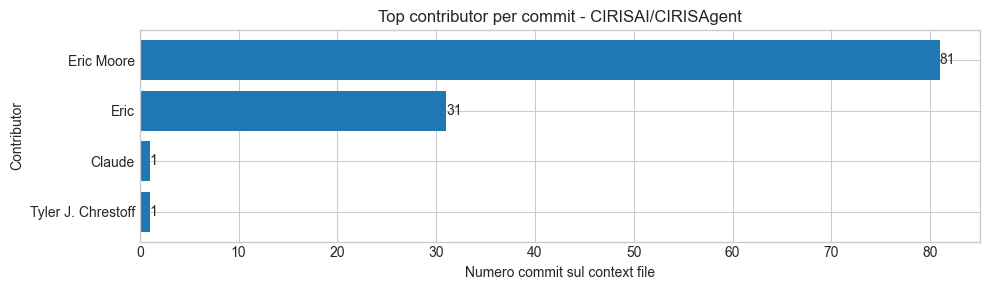

### Top commit relativi ai context file (per numero di context file toccati)

,hash,author,date,context_files,additions,deletions,changes,message,url
0,50a4e1de42a23c3e0153c53d90f994a60da9cb37,Eric,2025-06-25T04:32:02Z,1,520,339,859,"Major refactor: Eliminate Dict[str, Any] and achieve pytest green (#146)",https://github.com/CIRISAI/CIRISAgent/compare/2a5e717daad58a1469b1a89cfcd4c0946357a333...50a4e1de42a23c3e0153c53d90f994a60da9cb37
1,d0a86986389e1bc757cd10c219bd2ac519cb9d4f,Eric Moore,2025-06-29T22:44:37Z,1,82,611,693,refactor: rename ROOT to SYSTEM_ADMIN to avoid confusion with WA ROOT,https://github.com/CIRISAI/CIRISAgent/compare/8f9f68db9287410a3946990e2104757ebdf2eac2...d0a86986389e1bc757cd10c219bd2ac519cb9d4f
2,abe5d8b24ee559bf079ae3e59045fa691fa6ff93,Eric Moore,2025-06-16T15:21:06Z,1,82,448,530,"Zero Dict[str, Any] tolerance achieved + Identity profiles enriched",https://github.com/CIRISAI/CIRISAgent/compare/d63ab1822dfa36e92063237012ad80b98b22105f...abe5d8b24ee559bf079ae3e59045fa691fa6ff93
3,6409985566a33e3a31a299baf7cf1ae6ac55318b,Eric Moore,2025-06-05T01:38:59Z,1,309,5,314,working on final features,https://github.com/CIRISAI/CIRISAgent/compare/10b89dbc333841de2687fb17df64f20842ffcc76...6409985566a33e3a31a299baf7cf1ae6ac55318b
4,2a5e717daad58a1469b1a89cfcd4c0946357a333,Eric Moore,2025-06-20T15:02:55Z,1,270,26,296,"feat: redesign API to expose agent capabilities, not handlers",https://github.com/CIRISAI/CIRISAgent/compare/8bb08a326c2ee93aa827e83f328b9d924f1213c6...2a5e717daad58a1469b1a89cfcd4c0946357a333
5,825487b3f5c1a26ca481efe1527d06a32d9e7b52,Eric Moore,2025-06-19T04:09:27Z,1,95,170,265,feat: Complete BusManager refactoring and achieve pytest green,https://github.com/CIRISAI/CIRISAgent/compare/979a5b8b6d3d3493e28fdd8540521aec8c40383c...825487b3f5c1a26ca481efe1527d06a32d9e7b52
6,4b62d518de96fcc84c9b3a650ad3db02038661a5,Eric Moore,2025-06-16T15:32:48Z,1,179,82,261,"Update documentation for zero Dict[str, Any] achievement and agent profiles",https://github.com/CIRISAI/CIRISAgent/compare/abe5d8b24ee559bf079ae3e59045fa691fa6ff93...4b62d518de96fcc84c9b3a650ad3db02038661a5
7,56867a9919bceeba1b2b6f51bbe5d6b88731cdfd,Eric,2025-06-11T20:18:46Z,1,18,230,248,Document API server testing flow,https://github.com/CIRISAI/CIRISAgent/compare/d7cf076b44b429760bf915867ab6267c407cf54d...56867a9919bceeba1b2b6f51bbe5d6b88731cdfd
8,b67929a8d3ad77a75b3678bb59b38edee847ad1e,Eric Moore,2025-08-03T20:54:35Z,1,34,204,238,refactor: Major cleanup and test integration for better coverage,https://github.com/CIRISAI/CIRISAgent/compare/051b8ec13193dd190259c6f76474929238fa0812...b67929a8d3ad77a75b3678bb59b38edee847ad1e
9,84826f2326179483b5a3946d7b2a0f933d881057,Eric Moore,2025-06-16T00:31:04Z,1,220,4,224,Complete OAuth API endpoints and identity system refactor,https://github.com/CIRISAI/CIRISAgent/compare/2e8516451811f513c59b889822a48c13010fa3e8...84826f2326179483b5a3946d7b2a0f933d881057


### Commit context-file con maggiori modifiche (additions + deletions)

,hash,author,date,changes,additions,deletions,context_files,message,url
0,50a4e1de42a23c3e0153c53d90f994a60da9cb37,Eric,2025-06-25T04:32:02Z,859,520,339,1,"Major refactor: Eliminate Dict[str, Any] and achieve pytest green (#146)",https://github.com/CIRISAI/CIRISAgent/compare/2a5e717daad58a1469b1a89cfcd4c0946357a333...50a4e1de42a23c3e0153c53d90f994a60da9cb37
1,d0a86986389e1bc757cd10c219bd2ac519cb9d4f,Eric Moore,2025-06-29T22:44:37Z,693,82,611,1,refactor: rename ROOT to SYSTEM_ADMIN to avoid confusion with WA ROOT,https://github.com/CIRISAI/CIRISAgent/compare/8f9f68db9287410a3946990e2104757ebdf2eac2...d0a86986389e1bc757cd10c219bd2ac519cb9d4f
2,abe5d8b24ee559bf079ae3e59045fa691fa6ff93,Eric Moore,2025-06-16T15:21:06Z,530,82,448,1,"Zero Dict[str, Any] tolerance achieved + Identity profiles enriched",https://github.com/CIRISAI/CIRISAgent/compare/d63ab1822dfa36e92063237012ad80b98b22105f...abe5d8b24ee559bf079ae3e59045fa691fa6ff93
3,6409985566a33e3a31a299baf7cf1ae6ac55318b,Eric Moore,2025-06-05T01:38:59Z,314,309,5,1,working on final features,https://github.com/CIRISAI/CIRISAgent/compare/10b89dbc333841de2687fb17df64f20842ffcc76...6409985566a33e3a31a299baf7cf1ae6ac55318b
4,2a5e717daad58a1469b1a89cfcd4c0946357a333,Eric Moore,2025-06-20T15:02:55Z,296,270,26,1,"feat: redesign API to expose agent capabilities, not handlers",https://github.com/CIRISAI/CIRISAgent/compare/8bb08a326c2ee93aa827e83f328b9d924f1213c6...2a5e717daad58a1469b1a89cfcd4c0946357a333
5,825487b3f5c1a26ca481efe1527d06a32d9e7b52,Eric Moore,2025-06-19T04:09:27Z,265,95,170,1,feat: Complete BusManager refactoring and achieve pytest green,https://github.com/CIRISAI/CIRISAgent/compare/979a5b8b6d3d3493e28fdd8540521aec8c40383c...825487b3f5c1a26ca481efe1527d06a32d9e7b52
6,4b62d518de96fcc84c9b3a650ad3db02038661a5,Eric Moore,2025-06-16T15:32:48Z,261,179,82,1,"Update documentation for zero Dict[str, Any] achievement and agent profiles",https://github.com/CIRISAI/CIRISAgent/compare/abe5d8b24ee559bf079ae3e59045fa691fa6ff93...4b62d518de96fcc84c9b3a650ad3db02038661a5
7,56867a9919bceeba1b2b6f51bbe5d6b88731cdfd,Eric,2025-06-11T20:18:46Z,248,18,230,1,Document API server testing flow,https://github.com/CIRISAI/CIRISAgent/compare/d7cf076b44b429760bf915867ab6267c407cf54d...56867a9919bceeba1b2b6f51bbe5d6b88731cdfd
8,b67929a8d3ad77a75b3678bb59b38edee847ad1e,Eric Moore,2025-08-03T20:54:35Z,238,34,204,1,refactor: Major cleanup and test integration for better coverage,https://github.com/CIRISAI/CIRISAgent/compare/051b8ec13193dd190259c6f76474929238fa0812...b67929a8d3ad77a75b3678bb59b38edee847ad1e
9,84826f2326179483b5a3946d7b2a0f933d881057,Eric Moore,2025-06-16T00:31:04Z,224,220,4,1,Complete OAuth API endpoints and identity system refactor,https://github.com/CIRISAI/CIRISAgent/compare/2e8516451811f513c59b889822a48c13010fa3e8...84826f2326179483b5a3946d7b2a0f933d881057


In [98]:
show_repo_report("CIRISAI/CIRISAgent")

## UMEP-dev/SUEWS

### Contributor nella repository

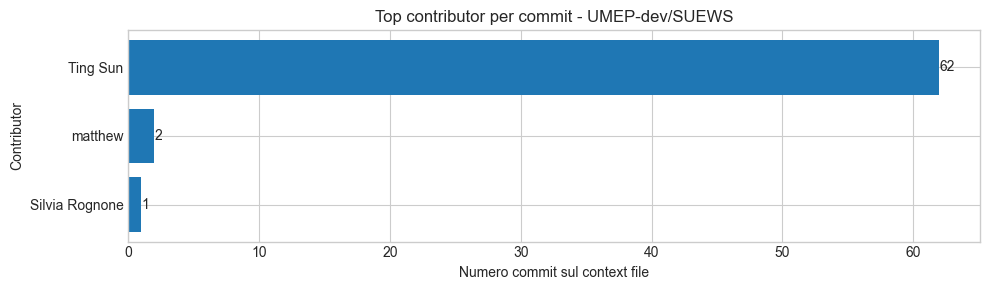

### Top commit relativi ai context file (per numero di context file toccati)

,hash,author,date,context_files,additions,deletions,changes,message,url
0,16f2b2bb00f72509982b7d303dec99638e84723f,Ting Sun,2025-08-07T09:12:32Z,1,3,616,619,feat: Add profile validation system for SUEWS conversion,https://github.com/UMEP-dev/SUEWS/compare/400f4c5ec68dfc980772caf49cf964a1e554a5f2...16f2b2bb00f72509982b7d303dec99638e84723f
1,61be9fcc42a6d5b3a6455231939ae8a108a39c8a,Ting Sun,2025-08-07T15:59:07Z,1,550,2,552,docs: restore CLAUDE.md from master with branch-specific reminders,https://github.com/UMEP-dev/SUEWS/compare/16f2b2bb00f72509982b7d303dec99638e84723f...61be9fcc42a6d5b3a6455231939ae8a108a39c8a
2,fc731f56f790794fc591de3ffb12b8de350ce574,Ting Sun,2025-06-23T11:15:44Z,1,5,523,528,feat: Streamline SUEWSSimulation with real benchmark data testing,https://github.com/UMEP-dev/SUEWS/compare/ae0b2f677622ea434084aeee3f88d8047867a68a...fc731f56f790794fc591de3ffb12b8de350ce574
3,9d6adaa318053a8b49cc78252eafa8ebc08c68ba,Ting Sun,2025-10-01T13:02:32Z,1,44,359,403,maint: tighten CLAUDE.md and .claude/ documentation,https://github.com/UMEP-dev/SUEWS/compare/e541dba53534836da9207933a5a2ac0b87034446...9d6adaa318053a8b49cc78252eafa8ebc08c68ba
4,fba230ecb5e0bea29b56444ac5259426b8629d15,Ting Sun,2025-07-18T12:37:36Z,1,20,342,362,refactor: eliminate duplication in worktree documentation,https://github.com/UMEP-dev/SUEWS/compare/7991f587680a10646e027b8592493d840c4f0334...fba230ecb5e0bea29b56444ac5259426b8629d15
5,06edb6e00aca8ac5cc95c878a6fc11d69459ae6c,Ting Sun,2025-07-18T12:52:09Z,1,22,334,356,Merge pull request #523 from UMEP-dev/docs/documentation-principles,https://github.com/UMEP-dev/SUEWS/compare/e9c4f6299f2aeed2ed26e51d8d03ed963efe601b...06edb6e00aca8ac5cc95c878a6fc11d69459ae6c
6,0925d7eab78537af18712d5171ff18aa7afd95ce,Ting Sun,2025-06-27T09:04:49Z,1,252,6,258,refactor: reorganize Claude Code workspace structure,https://github.com/UMEP-dev/SUEWS/compare/0f7d40af23758c74afb86a3058ce810bf176a340...0925d7eab78537af18712d5171ff18aa7afd95ce
7,e541dba53534836da9207933a5a2ac0b87034446,Ting Sun,2025-09-17T05:46:40Z,1,7,193,200,docs: Update CLAUDE.md for clarity and consistency,https://github.com/UMEP-dev/SUEWS/compare/2d81b126ca61cfa74cd9ddf54ce25cbef2fb9099...e541dba53534836da9207933a5a2ac0b87034446
8,5bf8a2a1af7db7f25d4635d9a6ecfd8114805e01,matthew,2025-07-15T15:57:25Z,1,135,1,136,docs: document QE/QH discrepancy investigation and fix,https://github.com/UMEP-dev/SUEWS/compare/8a9f6c7cb68ccf972f17d3c585fad81e1451af67...5bf8a2a1af7db7f25d4635d9a6ecfd8114805e01
9,8bdd49d57dd0689a1887f0dedba1a95ee3b16220,Ting Sun,2025-06-28T23:31:02Z,1,79,50,129,refactor: restructure .claude directory for clarity and coherence,https://github.com/UMEP-dev/SUEWS/compare/e03db0a44087b511d73cfbd0ef9c8d87bf6d2b89...8bdd49d57dd0689a1887f0dedba1a95ee3b16220


### Commit context-file con maggiori modifiche (additions + deletions)

,hash,author,date,changes,additions,deletions,context_files,message,url
0,16f2b2bb00f72509982b7d303dec99638e84723f,Ting Sun,2025-08-07T09:12:32Z,619,3,616,1,feat: Add profile validation system for SUEWS conversion,https://github.com/UMEP-dev/SUEWS/compare/400f4c5ec68dfc980772caf49cf964a1e554a5f2...16f2b2bb00f72509982b7d303dec99638e84723f
1,61be9fcc42a6d5b3a6455231939ae8a108a39c8a,Ting Sun,2025-08-07T15:59:07Z,552,550,2,1,docs: restore CLAUDE.md from master with branch-specific reminders,https://github.com/UMEP-dev/SUEWS/compare/16f2b2bb00f72509982b7d303dec99638e84723f...61be9fcc42a6d5b3a6455231939ae8a108a39c8a
2,fc731f56f790794fc591de3ffb12b8de350ce574,Ting Sun,2025-06-23T11:15:44Z,528,5,523,1,feat: Streamline SUEWSSimulation with real benchmark data testing,https://github.com/UMEP-dev/SUEWS/compare/ae0b2f677622ea434084aeee3f88d8047867a68a...fc731f56f790794fc591de3ffb12b8de350ce574
3,9d6adaa318053a8b49cc78252eafa8ebc08c68ba,Ting Sun,2025-10-01T13:02:32Z,403,44,359,1,maint: tighten CLAUDE.md and .claude/ documentation,https://github.com/UMEP-dev/SUEWS/compare/e541dba53534836da9207933a5a2ac0b87034446...9d6adaa318053a8b49cc78252eafa8ebc08c68ba
4,fba230ecb5e0bea29b56444ac5259426b8629d15,Ting Sun,2025-07-18T12:37:36Z,362,20,342,1,refactor: eliminate duplication in worktree documentation,https://github.com/UMEP-dev/SUEWS/compare/7991f587680a10646e027b8592493d840c4f0334...fba230ecb5e0bea29b56444ac5259426b8629d15
5,06edb6e00aca8ac5cc95c878a6fc11d69459ae6c,Ting Sun,2025-07-18T12:52:09Z,356,22,334,1,Merge pull request #523 from UMEP-dev/docs/documentation-principles,https://github.com/UMEP-dev/SUEWS/compare/e9c4f6299f2aeed2ed26e51d8d03ed963efe601b...06edb6e00aca8ac5cc95c878a6fc11d69459ae6c
6,0925d7eab78537af18712d5171ff18aa7afd95ce,Ting Sun,2025-06-27T09:04:49Z,258,252,6,1,refactor: reorganize Claude Code workspace structure,https://github.com/UMEP-dev/SUEWS/compare/0f7d40af23758c74afb86a3058ce810bf176a340...0925d7eab78537af18712d5171ff18aa7afd95ce
7,e541dba53534836da9207933a5a2ac0b87034446,Ting Sun,2025-09-17T05:46:40Z,200,7,193,1,docs: Update CLAUDE.md for clarity and consistency,https://github.com/UMEP-dev/SUEWS/compare/2d81b126ca61cfa74cd9ddf54ce25cbef2fb9099...e541dba53534836da9207933a5a2ac0b87034446
8,5bf8a2a1af7db7f25d4635d9a6ecfd8114805e01,matthew,2025-07-15T15:57:25Z,136,135,1,1,docs: document QE/QH discrepancy investigation and fix,https://github.com/UMEP-dev/SUEWS/compare/8a9f6c7cb68ccf972f17d3c585fad81e1451af67...5bf8a2a1af7db7f25d4635d9a6ecfd8114805e01
9,8bdd49d57dd0689a1887f0dedba1a95ee3b16220,Ting Sun,2025-06-28T23:31:02Z,129,79,50,1,refactor: restructure .claude directory for clarity and coherence,https://github.com/UMEP-dev/SUEWS/compare/e03db0a44087b511d73cfbd0ef9c8d87bf6d2b89...8bdd49d57dd0689a1887f0dedba1a95ee3b16220


In [99]:
show_repo_report("UMEP-dev/SUEWS")

## devill/refakts

### Contributor nella repository

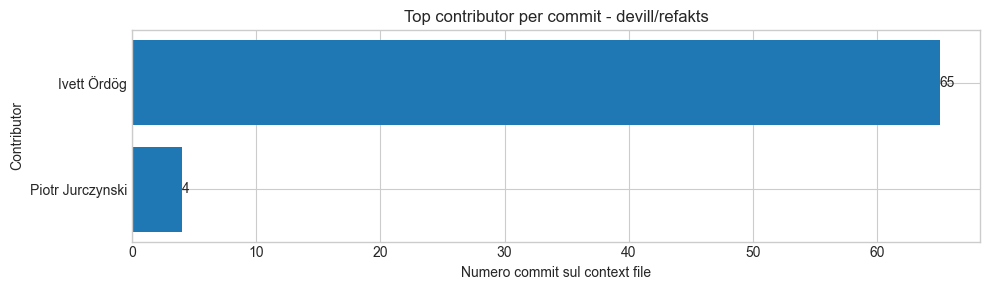

### Top commit relativi ai context file (per numero di context file toccati)

,hash,author,date,context_files,additions,deletions,changes,message,url
0,a1782a00563c840f68e983c7b67841ff2d48a5e4,Ivett Ördög,2025-07-26T15:19:32Z,1,80,304,384,Restructure CLAUDE.md and create specialized documentation guides,https://github.com/devill/refakts/compare/a7a54c1ae877cb854dfea77f970ca7fea7a20a61...a1782a00563c840f68e983c7b67841ff2d48a5e4
1,3520759bd48f94b182516fe17d2e3ad463c6c539,Piotr Jurczynski,2025-07-21T15:17:05Z,1,175,42,217,Merge remote-tracking branch 'upstream/main' into feat/sort-methods,https://github.com/devill/refakts/compare/b029e9e01e1fe43bd3108fd938f367547852f4d9...3520759bd48f94b182516fe17d2e3ad463c6c539
2,4d5d21e981ac0437425859a04e3a42e589773d67,Ivett Ördög,2025-07-04T11:46:29Z,1,32,112,144,Integrate roadmap into CLAUDE.md and clean up documentation,https://github.com/devill/refakts/compare/17922857dfbe42253fa39857c5671d8352f32778...4d5d21e981ac0437425859a04e3a42e589773d67
3,0c4af3c5be747de83651c841d7a50c640885f4d4,Ivett Ördög,2025-07-04T11:54:02Z,1,15,55,70,Resolve quality issues and improve documentation structure,https://github.com/devill/refakts/compare/4d5d21e981ac0437425859a04e3a42e589773d67...0c4af3c5be747de83651c841d7a50c640885f4d4
4,b6be74b1a6c1b85eedd3d3d55a3148042b15c0fa,Ivett Ördög,2025-07-02T20:30:21Z,1,38,25,63,Fix node-finding testing architecture,https://github.com/devill/refakts/compare/884a2f14fd659fd63be32df9a16a04c34530d364...b6be74b1a6c1b85eedd3d3d55a3148042b15c0fa
5,f599eadf069cf1448be435d586b8ac842eb04f16,Ivett Ördög,2025-07-02T18:19:52Z,1,61,0,61,Add AI-driven feature roadmap system,https://github.com/devill/refakts/compare/b081343f6c47fec0882151166a944beb3b85b86a...f599eadf069cf1448be435d586b8ac842eb04f16
6,3cfec8b216cf5ccffc2d9ade691f99d1cfcd106f,Ivett Ördög,2025-07-11T19:46:19Z,1,38,20,58,Hide incomplete commands from help and add --show-incomplete flag,https://github.com/devill/refakts/compare/900f001d2d7e9379672bee3ac99e2344f6838aaf...3cfec8b216cf5ccffc2d9ade691f99d1cfcd106f
7,5be8bc688e6d7be2c5714d7cd883eb1076f90cb8,Ivett Ördög,2025-06-30T09:12:57Z,1,50,7,57,CLAUDE.md cleanup.,https://github.com/devill/refakts/compare/e74a6e3adcbf0f795b1a784f5f6f00c1034cca7b...5be8bc688e6d7be2c5714d7cd883eb1076f90cb8
8,30dc72fc3008060300b04dfc503d699f2144ebb5,Ivett Ördög,2025-06-28T22:11:13Z,1,38,10,48,Add comprehensive refactoring completion tracking system,https://github.com/devill/refakts/compare/dd541362c4f5c9936a6106bab8275a76355d6a00...30dc72fc3008060300b04dfc503d699f2144ebb5
9,53543407153fe1a970fd085801b85baecaba8d5e,Ivett Ördög,2025-07-16T22:53:35Z,1,45,0,45,Document output handler architecture pattern for new commands,https://github.com/devill/refakts/compare/48559eac79e986aa10bd04a3f0d66e6a54078115...53543407153fe1a970fd085801b85baecaba8d5e


### Commit context-file con maggiori modifiche (additions + deletions)

,hash,author,date,changes,additions,deletions,context_files,message,url
0,a1782a00563c840f68e983c7b67841ff2d48a5e4,Ivett Ördög,2025-07-26T15:19:32Z,384,80,304,1,Restructure CLAUDE.md and create specialized documentation guides,https://github.com/devill/refakts/compare/a7a54c1ae877cb854dfea77f970ca7fea7a20a61...a1782a00563c840f68e983c7b67841ff2d48a5e4
1,3520759bd48f94b182516fe17d2e3ad463c6c539,Piotr Jurczynski,2025-07-21T15:17:05Z,217,175,42,1,Merge remote-tracking branch 'upstream/main' into feat/sort-methods,https://github.com/devill/refakts/compare/b029e9e01e1fe43bd3108fd938f367547852f4d9...3520759bd48f94b182516fe17d2e3ad463c6c539
2,4d5d21e981ac0437425859a04e3a42e589773d67,Ivett Ördög,2025-07-04T11:46:29Z,144,32,112,1,Integrate roadmap into CLAUDE.md and clean up documentation,https://github.com/devill/refakts/compare/17922857dfbe42253fa39857c5671d8352f32778...4d5d21e981ac0437425859a04e3a42e589773d67
3,0c4af3c5be747de83651c841d7a50c640885f4d4,Ivett Ördög,2025-07-04T11:54:02Z,70,15,55,1,Resolve quality issues and improve documentation structure,https://github.com/devill/refakts/compare/4d5d21e981ac0437425859a04e3a42e589773d67...0c4af3c5be747de83651c841d7a50c640885f4d4
4,b6be74b1a6c1b85eedd3d3d55a3148042b15c0fa,Ivett Ördög,2025-07-02T20:30:21Z,63,38,25,1,Fix node-finding testing architecture,https://github.com/devill/refakts/compare/884a2f14fd659fd63be32df9a16a04c34530d364...b6be74b1a6c1b85eedd3d3d55a3148042b15c0fa
5,f599eadf069cf1448be435d586b8ac842eb04f16,Ivett Ördög,2025-07-02T18:19:52Z,61,61,0,1,Add AI-driven feature roadmap system,https://github.com/devill/refakts/compare/b081343f6c47fec0882151166a944beb3b85b86a...f599eadf069cf1448be435d586b8ac842eb04f16
6,3cfec8b216cf5ccffc2d9ade691f99d1cfcd106f,Ivett Ördög,2025-07-11T19:46:19Z,58,38,20,1,Hide incomplete commands from help and add --show-incomplete flag,https://github.com/devill/refakts/compare/900f001d2d7e9379672bee3ac99e2344f6838aaf...3cfec8b216cf5ccffc2d9ade691f99d1cfcd106f
7,5be8bc688e6d7be2c5714d7cd883eb1076f90cb8,Ivett Ördög,2025-06-30T09:12:57Z,57,50,7,1,CLAUDE.md cleanup.,https://github.com/devill/refakts/compare/e74a6e3adcbf0f795b1a784f5f6f00c1034cca7b...5be8bc688e6d7be2c5714d7cd883eb1076f90cb8
8,30dc72fc3008060300b04dfc503d699f2144ebb5,Ivett Ördög,2025-06-28T22:11:13Z,48,38,10,1,Add comprehensive refactoring completion tracking system,https://github.com/devill/refakts/compare/dd541362c4f5c9936a6106bab8275a76355d6a00...30dc72fc3008060300b04dfc503d699f2144ebb5
9,53543407153fe1a970fd085801b85baecaba8d5e,Ivett Ördög,2025-07-16T22:53:35Z,45,45,0,1,Document output handler architecture pattern for new commands,https://github.com/devill/refakts/compare/48559eac79e986aa10bd04a3f0d66e6a54078115...53543407153fe1a970fd085801b85baecaba8d5e


In [103]:
show_repo_report("devill/refakts")

## evmts/guillotine

### Contributor nella repository

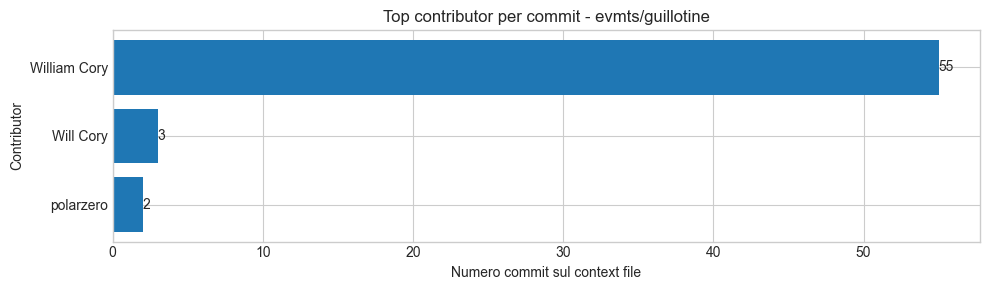

### Top commit relativi ai context file (per numero di context file toccati)

,hash,author,date,context_files,additions,deletions,changes,message,url
0,eb6345f69d4ca565f7381cd111deee03479511aa,William Cory,2025-08-25T03:23:33Z,1,87,995,1082,📚docs: consolidate agent guidelines into CLAUDE.md; symlink AGENTS.md\n\n🤖 Generated with [Claude Code](https://claude.ai/code)\n\nCo-Authored-By: Claude <noreply@anthropic.com>,https://github.com/evmts/guillotine/compare/567600efc8e933cc78bb619573298a70c3bf6f18...eb6345f69d4ca565f7381cd111deee03479511aa
1,6be5b8cef0e6506501fc00939b539f3f347f4c7f,William Cory,2025-09-14T08:21:09Z,1,97,419,516,📚 docs: Optimize CLAUDE.md files for token efficiency,https://github.com/evmts/guillotine/compare/c6ec0bc33172422fd5757c8e680d8a42fa25c504...6be5b8cef0e6506501fc00939b539f3f347f4c7f
2,bc3074349f00581dcf47c1a11a67f1b5582fdd73,William Cory,2025-07-11T11:03:14Z,1,275,131,406,📚 docs: enhance CLAUDE.md with comprehensive project documentation,https://github.com/evmts/guillotine/compare/1373872fdc108be7a874ac7bdb8997d9bca8a47f...bc3074349f00581dcf47c1a11a67f1b5582fdd73
3,59966f9920e6ea882f43e93c38a5c9bdbb6b1b11,William Cory,2025-09-12T23:38:04Z,1,319,0,319,docs: Add cli --help to CLAUDE.md,https://github.com/evmts/guillotine/compare/057cbd3a562383ba40f1f8df6639a4299852fc24...59966f9920e6ea882f43e93c38a5c9bdbb6b1b11
4,13764c9f2acdd5210d6c3ed3389aa2af98807b86,William Cory,2025-08-24T18:12:18Z,1,141,172,313,📚 docs: update architecture documentation for new EVM implementation,https://github.com/evmts/guillotine/compare/330c9f96d84e871d499dda4ea76528893e80fa6e...13764c9f2acdd5210d6c3ed3389aa2af98807b86
5,b8c1207d2d5358f628087ee30c62c3940fc27f56,William Cory,2025-08-24T00:01:42Z,1,180,0,180,📚 docs: add EVM architecture and coding guidelines to CLAUDE.md,https://github.com/evmts/guillotine/compare/9d33d0b0fee03455a1611a2b788ad93c9e150eef...b8c1207d2d5358f628087ee30c62c3940fc27f56
6,9eaf5a828324c105c586c89207000f74ffa27e43,William Cory,2025-07-18T20:51:48Z,1,108,30,138,🔧 refactor: eliminate Memory API footgun with safer shared buffer design,https://github.com/evmts/guillotine/compare/b6d06c3951703272a423e489638bde38e8c47a5f...9eaf5a828324c105c586c89207000f74ffa27e43
7,330c9f96d84e871d499dda4ea76528893e80fa6e,William Cory,2025-08-24T00:10:03Z,1,127,0,127,📚 docs: add advanced EVM architectural patterns to CLAUDE.md,https://github.com/evmts/guillotine/compare/b8c1207d2d5358f628087ee30c62c3940fc27f56...330c9f96d84e871d499dda4ea76528893e80fa6e
8,855e72f7b93a2ebfee6370bb59af34cf89df012c,William Cory,2025-09-14T20:05:38Z,1,72,17,89,📚 docs: Update CLAUDE.md files and architecture documentation,https://github.com/evmts/guillotine/compare/dca3cce67c8da2be41e9b6c61d9a8d7a1c997743...855e72f7b93a2ebfee6370bb59af34cf89df012c
9,b475375a4ae0b7c0ab5011e1dcc6438b2f9d567c,William Cory,2025-09-07T17:22:51Z,1,35,33,68,chore: Small claude cleanup,https://github.com/evmts/guillotine/compare/bcc1d9e4c9f4675cc7945a177ef613f17e59b137...b475375a4ae0b7c0ab5011e1dcc6438b2f9d567c


### Commit context-file con maggiori modifiche (additions + deletions)

,hash,author,date,changes,additions,deletions,context_files,message,url
0,eb6345f69d4ca565f7381cd111deee03479511aa,William Cory,2025-08-25T03:23:33Z,1082,87,995,1,📚docs: consolidate agent guidelines into CLAUDE.md; symlink AGENTS.md\n\n🤖 Generated with [Claude Code](https://claude.ai/code)\n\nCo-Authored-By: Claude <noreply@anthropic.com>,https://github.com/evmts/guillotine/compare/567600efc8e933cc78bb619573298a70c3bf6f18...eb6345f69d4ca565f7381cd111deee03479511aa
1,6be5b8cef0e6506501fc00939b539f3f347f4c7f,William Cory,2025-09-14T08:21:09Z,516,97,419,1,📚 docs: Optimize CLAUDE.md files for token efficiency,https://github.com/evmts/guillotine/compare/c6ec0bc33172422fd5757c8e680d8a42fa25c504...6be5b8cef0e6506501fc00939b539f3f347f4c7f
2,bc3074349f00581dcf47c1a11a67f1b5582fdd73,William Cory,2025-07-11T11:03:14Z,406,275,131,1,📚 docs: enhance CLAUDE.md with comprehensive project documentation,https://github.com/evmts/guillotine/compare/1373872fdc108be7a874ac7bdb8997d9bca8a47f...bc3074349f00581dcf47c1a11a67f1b5582fdd73
3,59966f9920e6ea882f43e93c38a5c9bdbb6b1b11,William Cory,2025-09-12T23:38:04Z,319,319,0,1,docs: Add cli --help to CLAUDE.md,https://github.com/evmts/guillotine/compare/057cbd3a562383ba40f1f8df6639a4299852fc24...59966f9920e6ea882f43e93c38a5c9bdbb6b1b11
4,13764c9f2acdd5210d6c3ed3389aa2af98807b86,William Cory,2025-08-24T18:12:18Z,313,141,172,1,📚 docs: update architecture documentation for new EVM implementation,https://github.com/evmts/guillotine/compare/330c9f96d84e871d499dda4ea76528893e80fa6e...13764c9f2acdd5210d6c3ed3389aa2af98807b86
5,b8c1207d2d5358f628087ee30c62c3940fc27f56,William Cory,2025-08-24T00:01:42Z,180,180,0,1,📚 docs: add EVM architecture and coding guidelines to CLAUDE.md,https://github.com/evmts/guillotine/compare/9d33d0b0fee03455a1611a2b788ad93c9e150eef...b8c1207d2d5358f628087ee30c62c3940fc27f56
6,9eaf5a828324c105c586c89207000f74ffa27e43,William Cory,2025-07-18T20:51:48Z,138,108,30,1,🔧 refactor: eliminate Memory API footgun with safer shared buffer design,https://github.com/evmts/guillotine/compare/b6d06c3951703272a423e489638bde38e8c47a5f...9eaf5a828324c105c586c89207000f74ffa27e43
7,330c9f96d84e871d499dda4ea76528893e80fa6e,William Cory,2025-08-24T00:10:03Z,127,127,0,1,📚 docs: add advanced EVM architectural patterns to CLAUDE.md,https://github.com/evmts/guillotine/compare/b8c1207d2d5358f628087ee30c62c3940fc27f56...330c9f96d84e871d499dda4ea76528893e80fa6e
8,855e72f7b93a2ebfee6370bb59af34cf89df012c,William Cory,2025-09-14T20:05:38Z,89,72,17,1,📚 docs: Update CLAUDE.md files and architecture documentation,https://github.com/evmts/guillotine/compare/dca3cce67c8da2be41e9b6c61d9a8d7a1c997743...855e72f7b93a2ebfee6370bb59af34cf89df012c
9,b475375a4ae0b7c0ab5011e1dcc6438b2f9d567c,William Cory,2025-09-07T17:22:51Z,68,35,33,1,chore: Small claude cleanup,https://github.com/evmts/guillotine/compare/bcc1d9e4c9f4675cc7945a177ef613f17e59b137...b475375a4ae0b7c0ab5011e1dcc6438b2f9d567c


In [105]:
show_repo_report("evmts/guillotine")

## kesslerio/attio-mcp-server

### Contributor nella repository

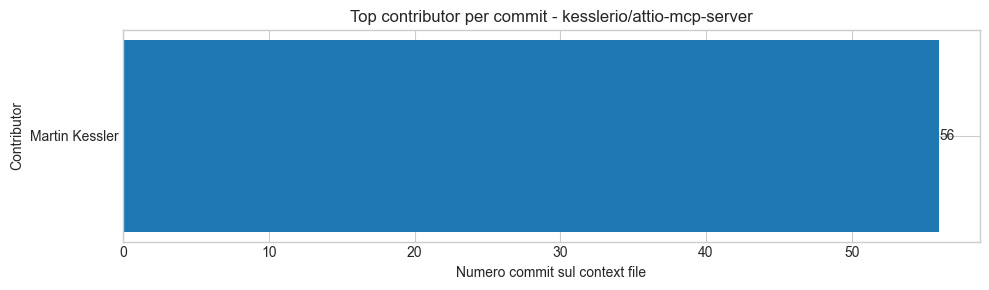

### Top commit relativi ai context file (per numero di context file toccati)

,hash,author,date,context_files,additions,deletions,changes,message,url
0,9fab4812af83d23326abfbac24551e8f324894eb,Martin Kessler,2025-09-16T17:32:28Z,1,158,373,531,Test(mcp): centralize e2e cleanup (#656),https://github.com/kesslerio/attio-mcp-server/compare/dea73eef63b89dd7f5452fcaf640560e2955fc40...9fab4812af83d23326abfbac24551e8f324894eb
1,950c6948805a786fa7c72a64b24f2b9ed858077a,Martin Kessler,2025-08-14T20:11:10Z,1,293,115,408,Fix: Complete resolution of E2E test failures achieving 100% success rate #480 (#483),https://github.com/kesslerio/attio-mcp-server/compare/ea7ac68d3f20e9556a29bc7f9f83dc1ed5042032...950c6948805a786fa7c72a64b24f2b9ed858077a
2,f0a1a460fcb184e05db10e15d09d7a6637376745,Martin Kessler,2025-08-25T18:02:25Z,1,102,305,407,fix(e2e): surgical fixes for error-handling test failures (#524),https://github.com/kesslerio/attio-mcp-server/compare/afd4ccd70aec3e8553ce7b52efc024cc899fedb2...f0a1a460fcb184e05db10e15d09d7a6637376745
3,820fb004508791393d63da7cf5748d448a803cb8,Martin Kessler,2025-08-06T17:14:49Z,1,106,266,372,Feature: Phase 2 Performance Optimization Implementation (#379),https://github.com/kesslerio/attio-mcp-server/compare/4e275f70196a88f29ed6d80e23da291047db2843...820fb004508791393d63da7cf5748d448a803cb8
4,b1b5cb609b653a5fb1f9b8451327b32d1760683a,Martin Kessler,2025-05-29T21:45:49Z,1,73,167,240,Fix: Strategic Test Cleanup Phase 1 - Quality over Quantity Approach,https://github.com/kesslerio/attio-mcp-server/compare/f25fd33f00366e43fef79e60ebcb3272ba292a0b...b1b5cb609b653a5fb1f9b8451327b32d1760683a
5,af4bf105a9328549e04bd7783d47a36a2b171ff8,Martin Kessler,2025-05-18T18:26:52Z,1,0,162,162,Fix: MCP connection errors and schema compatibility issues (#128),https://github.com/kesslerio/attio-mcp-server/compare/c939ecebf904797b72d5d1b6318cebf50cadc311...af4bf105a9328549e04bd7783d47a36a2b171ff8
6,8ced335c73f2220fa79a9393a7dcc49747612b65,Martin Kessler,2025-08-06T05:51:58Z,1,100,16,116,Fix: Permanent solution for E2E test environment variable loading (#376),https://github.com/kesslerio/attio-mcp-server/compare/4fe446048897b4b7386bcd040673b002be6fd6bd...8ced335c73f2220fa79a9393a7dcc49747612b65
7,ca6251cb37fbc89fe479d401e54d7a1de88fb391,Martin Kessler,2025-05-19T19:10:05Z,1,44,54,98,Chore: Remove IDE-specific files from git and update .gitignore (#136),https://github.com/kesslerio/attio-mcp-server/compare/af4bf105a9328549e04bd7783d47a36a2b171ff8...ca6251cb37fbc89fe479d401e54d7a1de88fb391
8,952b749e07e30cca149d6b59c5ce101ffab5f45b,Martin Kessler,2026-01-06T02:35:00Z,1,52,30,82,Chore: Migrate from npm to bun package manager (#1094),https://github.com/kesslerio/attio-mcp-server/compare/f93d3c67356f6bc94906ce6572baf45be626edaa...952b749e07e30cca149d6b59c5ce101ffab5f45b
9,f25fd33f00366e43fef79e60ebcb3272ba292a0b,Martin Kessler,2025-05-29T03:08:45Z,1,67,2,69,Feature: Implement test coverage reporting and TDD development environment (#310),https://github.com/kesslerio/attio-mcp-server/compare/5fe100b976591555c0dc913013c94993b41373a5...f25fd33f00366e43fef79e60ebcb3272ba292a0b


### Commit context-file con maggiori modifiche (additions + deletions)

,hash,author,date,changes,additions,deletions,context_files,message,url
0,9fab4812af83d23326abfbac24551e8f324894eb,Martin Kessler,2025-09-16T17:32:28Z,531,158,373,1,Test(mcp): centralize e2e cleanup (#656),https://github.com/kesslerio/attio-mcp-server/compare/dea73eef63b89dd7f5452fcaf640560e2955fc40...9fab4812af83d23326abfbac24551e8f324894eb
1,950c6948805a786fa7c72a64b24f2b9ed858077a,Martin Kessler,2025-08-14T20:11:10Z,408,293,115,1,Fix: Complete resolution of E2E test failures achieving 100% success rate #480 (#483),https://github.com/kesslerio/attio-mcp-server/compare/ea7ac68d3f20e9556a29bc7f9f83dc1ed5042032...950c6948805a786fa7c72a64b24f2b9ed858077a
2,f0a1a460fcb184e05db10e15d09d7a6637376745,Martin Kessler,2025-08-25T18:02:25Z,407,102,305,1,fix(e2e): surgical fixes for error-handling test failures (#524),https://github.com/kesslerio/attio-mcp-server/compare/afd4ccd70aec3e8553ce7b52efc024cc899fedb2...f0a1a460fcb184e05db10e15d09d7a6637376745
3,820fb004508791393d63da7cf5748d448a803cb8,Martin Kessler,2025-08-06T17:14:49Z,372,106,266,1,Feature: Phase 2 Performance Optimization Implementation (#379),https://github.com/kesslerio/attio-mcp-server/compare/4e275f70196a88f29ed6d80e23da291047db2843...820fb004508791393d63da7cf5748d448a803cb8
4,b1b5cb609b653a5fb1f9b8451327b32d1760683a,Martin Kessler,2025-05-29T21:45:49Z,240,73,167,1,Fix: Strategic Test Cleanup Phase 1 - Quality over Quantity Approach,https://github.com/kesslerio/attio-mcp-server/compare/f25fd33f00366e43fef79e60ebcb3272ba292a0b...b1b5cb609b653a5fb1f9b8451327b32d1760683a
5,af4bf105a9328549e04bd7783d47a36a2b171ff8,Martin Kessler,2025-05-18T18:26:52Z,162,0,162,1,Fix: MCP connection errors and schema compatibility issues (#128),https://github.com/kesslerio/attio-mcp-server/compare/c939ecebf904797b72d5d1b6318cebf50cadc311...af4bf105a9328549e04bd7783d47a36a2b171ff8
6,8ced335c73f2220fa79a9393a7dcc49747612b65,Martin Kessler,2025-08-06T05:51:58Z,116,100,16,1,Fix: Permanent solution for E2E test environment variable loading (#376),https://github.com/kesslerio/attio-mcp-server/compare/4fe446048897b4b7386bcd040673b002be6fd6bd...8ced335c73f2220fa79a9393a7dcc49747612b65
7,ca6251cb37fbc89fe479d401e54d7a1de88fb391,Martin Kessler,2025-05-19T19:10:05Z,98,44,54,1,Chore: Remove IDE-specific files from git and update .gitignore (#136),https://github.com/kesslerio/attio-mcp-server/compare/af4bf105a9328549e04bd7783d47a36a2b171ff8...ca6251cb37fbc89fe479d401e54d7a1de88fb391
8,952b749e07e30cca149d6b59c5ce101ffab5f45b,Martin Kessler,2026-01-06T02:35:00Z,82,52,30,1,Chore: Migrate from npm to bun package manager (#1094),https://github.com/kesslerio/attio-mcp-server/compare/f93d3c67356f6bc94906ce6572baf45be626edaa...952b749e07e30cca149d6b59c5ce101ffab5f45b
9,f25fd33f00366e43fef79e60ebcb3272ba292a0b,Martin Kessler,2025-05-29T03:08:45Z,69,67,2,1,Feature: Implement test coverage reporting and TDD development environment (#310),https://github.com/kesslerio/attio-mcp-server/compare/5fe100b976591555c0dc913013c94993b41373a5...f25fd33f00366e43fef79e60ebcb3272ba292a0b


In [107]:
show_repo_report("kesslerio/attio-mcp-server")

## lbds137/tzurot

### Contributor nella repository

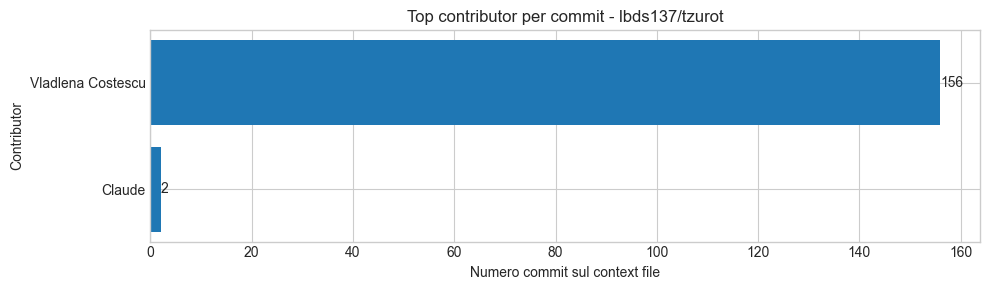

### Top commit relativi ai context file (per numero di context file toccati)

,hash,author,date,context_files,additions,deletions,changes,message,url
0,2677be93a53873cd294002a9e72c5ed21d8d5265,Vladlena Costescu,2025-07-16T23:26:19Z,1,167,1063,1230,Update CLAUDE.md following guidance from Claude web,https://github.com/lbds137/tzurot/compare/50d1e196cc745dd48fc7cc126cdb2a77b7cdea3c...2677be93a53873cd294002a9e72c5ed21d8d5265
1,3e876e8826ae3c4482d96784a1cd8196270fd1f9,Vladlena Costescu,2025-12-20T21:51:10Z,1,123,897,1020,docs: optimize skills and CLAUDE.md for progressive disclosure,https://github.com/lbds137/tzurot/compare/8ad6afa0e06de8398910b182fd6bd508c29b8972...3e876e8826ae3c4482d96784a1cd8196270fd1f9
2,c1f6b0663f480c7535cf3316409738e76fb0afa0,Vladlena Costescu,2025-10-23T01:04:19Z,1,339,333,672,docs: update all docs to reflect v3 deployment reality,https://github.com/lbds137/tzurot/compare/d3bebf098facba8042e5ab37cfd031c7c5534fe2...c1f6b0663f480c7535cf3316409738e76fb0afa0
3,b8b4c494d7bd7db3e10770523c9d24b39639d33c,Vladlena Costescu,2026-02-02T02:34:03Z,1,87,536,623,chore: optimize Claude Code configuration for reduced context,https://github.com/lbds137/tzurot/compare/ea7465710eaae044eeda26b0ec140617bf5e5a29...b8b4c494d7bd7db3e10770523c9d24b39639d33c
4,dd3e25c15fb0e1f2eb7e1d08c1a45273cad08f9e,Vladlena Costescu,2025-06-20T21:09:11Z,1,69,332,401,docs: optimize CLAUDE.md for space efficiency,https://github.com/lbds137/tzurot/compare/0a0c6e0a0a9862ad6510999efc3d4d7a18e31da1...dd3e25c15fb0e1f2eb7e1d08c1a45273cad08f9e
5,5c097a402f99285bce97a3d1d9de22cac8d6ed99,Vladlena Costescu,2025-11-19T18:42:55Z,1,70,296,366,refactor: streamline CLAUDE.md and add comprehensive security skill,https://github.com/lbds137/tzurot/compare/f6663961244e9accd50c6bd79e05e0f041feed16...5c097a402f99285bce97a3d1d9de22cac8d6ed99
6,aaf8e9c34b60052fb252ef330d2901cb1ec4ff46,Vladlena Costescu,2025-06-03T02:30:56Z,1,37,306,343,docs: optimize CLAUDE.md for better performance and readability,https://github.com/lbds137/tzurot/compare/fea8c40652599de1d5e883cb219a3b7b922fad84...aaf8e9c34b60052fb252ef330d2901cb1ec4ff46
7,74c596d07b798cd0dc7f415aecaa59e0e2f5a8f6,Vladlena Costescu,2025-05-27T22:19:40Z,1,238,104,342,docs: Add comprehensive testing and timer pattern enforcement,https://github.com/lbds137/tzurot/compare/938054d20df4690073ffdd45f9b73d698ecf08cf...74c596d07b798cd0dc7f415aecaa59e0e2f5a8f6
8,fe5e7f70edfdd2c8c7f5f2703dce3914e079892e,Vladlena Costescu,2025-06-11T03:47:59Z,1,37,276,313,chore: reduce CLAUDE.md size from 44k to 37k characters,https://github.com/lbds137/tzurot/compare/0ba038aeb7fec2e07ffe7c0fb63668cb63352945...fe5e7f70edfdd2c8c7f5f2703dce3914e079892e
9,50d1e196cc745dd48fc7cc126cdb2a77b7cdea3c,Vladlena Costescu,2025-07-16T02:56:33Z,1,294,0,294,docs: add comprehensive refactoring guidelines to prevent functionality loss,https://github.com/lbds137/tzurot/compare/b5b90cf08d8ed0f2cc9a2a991a6e65839dbdcc57...50d1e196cc745dd48fc7cc126cdb2a77b7cdea3c


### Commit context-file con maggiori modifiche (additions + deletions)

,hash,author,date,changes,additions,deletions,context_files,message,url
0,2677be93a53873cd294002a9e72c5ed21d8d5265,Vladlena Costescu,2025-07-16T23:26:19Z,1230,167,1063,1,Update CLAUDE.md following guidance from Claude web,https://github.com/lbds137/tzurot/compare/50d1e196cc745dd48fc7cc126cdb2a77b7cdea3c...2677be93a53873cd294002a9e72c5ed21d8d5265
1,3e876e8826ae3c4482d96784a1cd8196270fd1f9,Vladlena Costescu,2025-12-20T21:51:10Z,1020,123,897,1,docs: optimize skills and CLAUDE.md for progressive disclosure,https://github.com/lbds137/tzurot/compare/8ad6afa0e06de8398910b182fd6bd508c29b8972...3e876e8826ae3c4482d96784a1cd8196270fd1f9
2,c1f6b0663f480c7535cf3316409738e76fb0afa0,Vladlena Costescu,2025-10-23T01:04:19Z,672,339,333,1,docs: update all docs to reflect v3 deployment reality,https://github.com/lbds137/tzurot/compare/d3bebf098facba8042e5ab37cfd031c7c5534fe2...c1f6b0663f480c7535cf3316409738e76fb0afa0
3,b8b4c494d7bd7db3e10770523c9d24b39639d33c,Vladlena Costescu,2026-02-02T02:34:03Z,623,87,536,1,chore: optimize Claude Code configuration for reduced context,https://github.com/lbds137/tzurot/compare/ea7465710eaae044eeda26b0ec140617bf5e5a29...b8b4c494d7bd7db3e10770523c9d24b39639d33c
4,dd3e25c15fb0e1f2eb7e1d08c1a45273cad08f9e,Vladlena Costescu,2025-06-20T21:09:11Z,401,69,332,1,docs: optimize CLAUDE.md for space efficiency,https://github.com/lbds137/tzurot/compare/0a0c6e0a0a9862ad6510999efc3d4d7a18e31da1...dd3e25c15fb0e1f2eb7e1d08c1a45273cad08f9e
5,5c097a402f99285bce97a3d1d9de22cac8d6ed99,Vladlena Costescu,2025-11-19T18:42:55Z,366,70,296,1,refactor: streamline CLAUDE.md and add comprehensive security skill,https://github.com/lbds137/tzurot/compare/f6663961244e9accd50c6bd79e05e0f041feed16...5c097a402f99285bce97a3d1d9de22cac8d6ed99
6,aaf8e9c34b60052fb252ef330d2901cb1ec4ff46,Vladlena Costescu,2025-06-03T02:30:56Z,343,37,306,1,docs: optimize CLAUDE.md for better performance and readability,https://github.com/lbds137/tzurot/compare/fea8c40652599de1d5e883cb219a3b7b922fad84...aaf8e9c34b60052fb252ef330d2901cb1ec4ff46
7,74c596d07b798cd0dc7f415aecaa59e0e2f5a8f6,Vladlena Costescu,2025-05-27T22:19:40Z,342,238,104,1,docs: Add comprehensive testing and timer pattern enforcement,https://github.com/lbds137/tzurot/compare/938054d20df4690073ffdd45f9b73d698ecf08cf...74c596d07b798cd0dc7f415aecaa59e0e2f5a8f6
8,fe5e7f70edfdd2c8c7f5f2703dce3914e079892e,Vladlena Costescu,2025-06-11T03:47:59Z,313,37,276,1,chore: reduce CLAUDE.md size from 44k to 37k characters,https://github.com/lbds137/tzurot/compare/0ba038aeb7fec2e07ffe7c0fb63668cb63352945...fe5e7f70edfdd2c8c7f5f2703dce3914e079892e
9,50d1e196cc745dd48fc7cc126cdb2a77b7cdea3c,Vladlena Costescu,2025-07-16T02:56:33Z,294,294,0,1,docs: add comprehensive refactoring guidelines to prevent functionality loss,https://github.com/lbds137/tzurot/compare/b5b90cf08d8ed0f2cc9a2a991a6e65839dbdcc57...50d1e196cc745dd48fc7cc126cdb2a77b7cdea3c


In [108]:
show_repo_report("lbds137/tzurot")

## steipete/Peekaboo

### Contributor nella repository

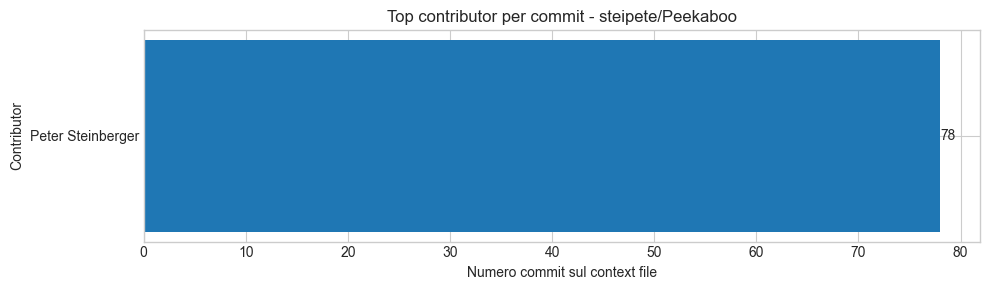

### Top commit relativi ai context file (per numero di context file toccati)

,hash,author,date,context_files,additions,deletions,changes,message,url
0,fba564f14df7abca86f2f906e2ee94085ed5be0b,Peter Steinberger,2025-07-26T18:06:16Z,1,57,967,1024,docs: Streamline CLAUDE.md and add OpenAI API references,https://github.com/openclaw/Peekaboo/compare/80032e0940d21bc042c068db85dce21911be7ada...fba564f14df7abca86f2f906e2ee94085ed5be0b
1,cdcc9504826fe923b7d903a1a4f32c630ececb9e,Peter Steinberger,2025-08-04T22:28:09Z,1,50,444,494,Restore CLAUDE.md to cleaned up version,https://github.com/openclaw/Peekaboo/compare/215788eec49bfb1d1b50548deb9ab1271c130bc1...cdcc9504826fe923b7d903a1a4f32c630ececb9e
2,57bb4005ccbec9b08c181c4bf4a16b8c799ad8f1,Peter Steinberger,2025-07-08T23:35:15Z,1,371,22,393,docs: update documentation and build configuration,https://github.com/openclaw/Peekaboo/compare/191c430963d1f6c11863aad3bf3c0fec38ba7bcf...57bb4005ccbec9b08c181c4bf4a16b8c799ad8f1
3,27ac539656c0f029d3c6c1291763405b8cc048a0,Peter Steinberger,2025-08-07T10:44:13Z,1,34,240,274,feat: Expose all Peekaboo tools to agent and fix API issues,https://github.com/openclaw/Peekaboo/compare/2c3b95824af4dce650c7faa9ff7d08b85d0764f9...27ac539656c0f029d3c6c1291763405b8cc048a0
4,9a5e62730d45b6bdd8a4d328acd28f2133b53c8f,Peter Steinberger,2025-07-26T05:40:07Z,1,156,18,174,feat: Update Mac app with CLI agent improvements,https://github.com/openclaw/Peekaboo/compare/664d6c2e37d5fa9e4fb25d1b4369f9c59a67c1b0...9a5e62730d45b6bdd8a4d328acd28f2133b53c8f
5,1e657b5c341e5a4785b99d3e3d7e6a5db26edc35,Peter Steinberger,2025-07-25T00:02:25Z,1,113,0,113,feat: Add comprehensive Playground test app with logging utility,https://github.com/openclaw/Peekaboo/compare/57bb4005ccbec9b08c181c4bf4a16b8c799ad8f1...1e657b5c341e5a4785b99d3e3d7e6a5db26edc35
6,f0c50f0890c13cfb102ebb0227138ad0cff93265,Peter Steinberger,2025-07-07T14:00:12Z,1,111,1,112,feat: Add vtlog utility for unified logging access,https://github.com/openclaw/Peekaboo/compare/cceb2d071696b5e37982c539922b2a5cc3cac191...f0c50f0890c13cfb102ebb0227138ad0cff93265
7,11d054a8e3723921153507f2e9d8a96ae8af96a6,Peter Steinberger,2025-07-26T15:43:36Z,1,63,28,91,feat: Enhanced Poltergeist with build cancellation and clearer instructions,https://github.com/openclaw/Peekaboo/compare/ffcfaa052d97501b08a89d47e9d0c1906d0e1a4b...11d054a8e3723921153507f2e9d8a96ae8af96a6
8,da89f1dc850522c0cbbf4e501147b73a7a1976f4,Peter Steinberger,2025-07-26T21:17:32Z,1,79,4,83,feat: Add native Anthropic SDK support with Claude 4 models,https://github.com/openclaw/Peekaboo/compare/bd3f274a51208f3f18ffcc71df15acbdfa772a5c...da89f1dc850522c0cbbf4e501147b73a7a1976f4
9,215788eec49bfb1d1b50548deb9ab1271c130bc1,Peter Steinberger,2025-08-04T22:03:15Z,1,76,6,82,Fix CI configuration for Tachikoma integration,https://github.com/openclaw/Peekaboo/compare/e5975bf6f158c48ac2bc665b22681adab1317a93...215788eec49bfb1d1b50548deb9ab1271c130bc1


### Commit context-file con maggiori modifiche (additions + deletions)

,hash,author,date,changes,additions,deletions,context_files,message,url
0,fba564f14df7abca86f2f906e2ee94085ed5be0b,Peter Steinberger,2025-07-26T18:06:16Z,1024,57,967,1,docs: Streamline CLAUDE.md and add OpenAI API references,https://github.com/openclaw/Peekaboo/compare/80032e0940d21bc042c068db85dce21911be7ada...fba564f14df7abca86f2f906e2ee94085ed5be0b
1,cdcc9504826fe923b7d903a1a4f32c630ececb9e,Peter Steinberger,2025-08-04T22:28:09Z,494,50,444,1,Restore CLAUDE.md to cleaned up version,https://github.com/openclaw/Peekaboo/compare/215788eec49bfb1d1b50548deb9ab1271c130bc1...cdcc9504826fe923b7d903a1a4f32c630ececb9e
2,57bb4005ccbec9b08c181c4bf4a16b8c799ad8f1,Peter Steinberger,2025-07-08T23:35:15Z,393,371,22,1,docs: update documentation and build configuration,https://github.com/openclaw/Peekaboo/compare/191c430963d1f6c11863aad3bf3c0fec38ba7bcf...57bb4005ccbec9b08c181c4bf4a16b8c799ad8f1
3,27ac539656c0f029d3c6c1291763405b8cc048a0,Peter Steinberger,2025-08-07T10:44:13Z,274,34,240,1,feat: Expose all Peekaboo tools to agent and fix API issues,https://github.com/openclaw/Peekaboo/compare/2c3b95824af4dce650c7faa9ff7d08b85d0764f9...27ac539656c0f029d3c6c1291763405b8cc048a0
4,9a5e62730d45b6bdd8a4d328acd28f2133b53c8f,Peter Steinberger,2025-07-26T05:40:07Z,174,156,18,1,feat: Update Mac app with CLI agent improvements,https://github.com/openclaw/Peekaboo/compare/664d6c2e37d5fa9e4fb25d1b4369f9c59a67c1b0...9a5e62730d45b6bdd8a4d328acd28f2133b53c8f
5,1e657b5c341e5a4785b99d3e3d7e6a5db26edc35,Peter Steinberger,2025-07-25T00:02:25Z,113,113,0,1,feat: Add comprehensive Playground test app with logging utility,https://github.com/openclaw/Peekaboo/compare/57bb4005ccbec9b08c181c4bf4a16b8c799ad8f1...1e657b5c341e5a4785b99d3e3d7e6a5db26edc35
6,f0c50f0890c13cfb102ebb0227138ad0cff93265,Peter Steinberger,2025-07-07T14:00:12Z,112,111,1,1,feat: Add vtlog utility for unified logging access,https://github.com/openclaw/Peekaboo/compare/cceb2d071696b5e37982c539922b2a5cc3cac191...f0c50f0890c13cfb102ebb0227138ad0cff93265
7,11d054a8e3723921153507f2e9d8a96ae8af96a6,Peter Steinberger,2025-07-26T15:43:36Z,91,63,28,1,feat: Enhanced Poltergeist with build cancellation and clearer instructions,https://github.com/openclaw/Peekaboo/compare/ffcfaa052d97501b08a89d47e9d0c1906d0e1a4b...11d054a8e3723921153507f2e9d8a96ae8af96a6
8,da89f1dc850522c0cbbf4e501147b73a7a1976f4,Peter Steinberger,2025-07-26T21:17:32Z,83,79,4,1,feat: Add native Anthropic SDK support with Claude 4 models,https://github.com/openclaw/Peekaboo/compare/bd3f274a51208f3f18ffcc71df15acbdfa772a5c...da89f1dc850522c0cbbf4e501147b73a7a1976f4
9,215788eec49bfb1d1b50548deb9ab1271c130bc1,Peter Steinberger,2025-08-04T22:03:15Z,82,76,6,1,Fix CI configuration for Tachikoma integration,https://github.com/openclaw/Peekaboo/compare/e5975bf6f158c48ac2bc665b22681adab1317a93...215788eec49bfb1d1b50548deb9ab1271c130bc1


In [111]:
show_repo_report("steipete/Peekaboo")

## MontrealAI/AGI-Alpha-Agent-v0

### Contributor nella repository

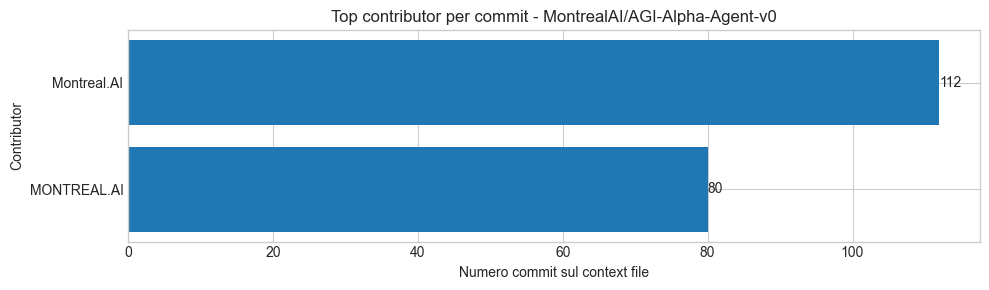

### Top commit relativi ai context file (per numero di context file toccati)

,hash,author,date,context_files,additions,deletions,changes,message,url
0,80cb187b1b93510cf227a6271e9b6ebb50d779b0,Montreal.AI,2025-05-25T15:56:40Z,1,43,9,52,[alpha_factory] docs: summarize env vars in table,https://github.com/MontrealAI/AGI-Alpha-Agent-v0/compare/9a54f8b9e7278d43aeda673c63d70fd0838498a0...80cb187b1b93510cf227a6271e9b6ebb50d779b0
1,c2145f2980df461144a0f6a9ffe0bc58c6a271a2,Montreal.AI,2025-05-25T18:10:07Z,1,20,26,46,docs: clarify wheel signing steps,https://github.com/MontrealAI/AGI-Alpha-Agent-v0/compare/aefead4e27d97bbedac46d16d972effeec618acf...c2145f2980df461144a0f6a9ffe0bc58c6a271a2
2,7e6ac4871800cb6135241351da2bec9d6f0596da,Montreal.AI,2025-05-25T18:39:12Z,1,17,18,35,docs: add offline setup section,https://github.com/MontrealAI/AGI-Alpha-Agent-v0/compare/2a8a6f52755c93957600bd8d950b539db3e53719...7e6ac4871800cb6135241351da2bec9d6f0596da
3,b6b7bb389d1ce3cc2256e57cc177785d659be0b7,Montreal.AI,2025-05-25T15:59:57Z,1,18,15,33,docs: clarify offline wheelhouse instructions,https://github.com/MontrealAI/AGI-Alpha-Agent-v0/compare/80cb187b1b93510cf227a6271e9b6ebb50d779b0...b6b7bb389d1ce3cc2256e57cc177785d659be0b7
4,d64aa367ecfd787f6ebd993bdbfe280190a161ad,Montreal.AI,2025-05-25T13:10:11Z,1,16,14,30,docs: clarify wheelhouse usage,https://github.com/MontrealAI/AGI-Alpha-Agent-v0/compare/7709ff6d8c57b9607350b2ac7d083c39592ae395...d64aa367ecfd787f6ebd993bdbfe280190a161ad
5,afc9f67e9999cdb454f4a2a3e9e5e8affa3da709,Montreal.AI,2025-05-22T02:45:59Z,1,14,9,23,Improve setup and dependency checks,https://github.com/MontrealAI/AGI-Alpha-Agent-v0/compare/a1c705ddfc95160785fe224e28bb038f0d2594ad...afc9f67e9999cdb454f4a2a3e9e5e8affa3da709
6,41af67d13b7edc3acb39bee193b6ee6f85bd3793,Montreal.AI,2025-05-22T03:01:11Z,1,11,10,21,Fix newline,https://github.com/MontrealAI/AGI-Alpha-Agent-v0/compare/afc9f67e9999cdb454f4a2a3e9e5e8affa3da709...41af67d13b7edc3acb39bee193b6ee6f85bd3793
7,3499395046aa77a5ea081a75e369fe0f0bdd5815,Montreal.AI,2025-05-22T03:47:43Z,1,10,10,20,Improve setup script and contributor guide,https://github.com/MontrealAI/AGI-Alpha-Agent-v0/compare/ebacdf2fca53ce1e6c40f7f5f546467350b1e1fb...3499395046aa77a5ea081a75e369fe0f0bdd5815
8,966be28251cd35630201a0cfc48b10fb26faf1ac,Montreal.AI,2025-05-22T02:21:08Z,1,7,13,20,Add minimal Codex setup script and update AGENTS guidelines,https://github.com/MontrealAI/AGI-Alpha-Agent-v0/compare/43cf7b6a89ae298f6e0df44cb47a6d7cd15e8579...966be28251cd35630201a0cfc48b10fb26faf1ac
9,a1b5c18fa4004741c6508e70c8fb18cbbc85b45d,MONTREAL.AI,2025-06-18T03:57:04Z,1,10,9,19,docs: add wheelhouse script,https://github.com/MontrealAI/AGI-Alpha-Agent-v0/compare/2f7c36cc2198ea29b1d1bfeafcdacb62a7bd64c8...a1b5c18fa4004741c6508e70c8fb18cbbc85b45d


### Commit context-file con maggiori modifiche (additions + deletions)

,hash,author,date,changes,additions,deletions,context_files,message,url
0,80cb187b1b93510cf227a6271e9b6ebb50d779b0,Montreal.AI,2025-05-25T15:56:40Z,52,43,9,1,[alpha_factory] docs: summarize env vars in table,https://github.com/MontrealAI/AGI-Alpha-Agent-v0/compare/9a54f8b9e7278d43aeda673c63d70fd0838498a0...80cb187b1b93510cf227a6271e9b6ebb50d779b0
1,c2145f2980df461144a0f6a9ffe0bc58c6a271a2,Montreal.AI,2025-05-25T18:10:07Z,46,20,26,1,docs: clarify wheel signing steps,https://github.com/MontrealAI/AGI-Alpha-Agent-v0/compare/aefead4e27d97bbedac46d16d972effeec618acf...c2145f2980df461144a0f6a9ffe0bc58c6a271a2
2,7e6ac4871800cb6135241351da2bec9d6f0596da,Montreal.AI,2025-05-25T18:39:12Z,35,17,18,1,docs: add offline setup section,https://github.com/MontrealAI/AGI-Alpha-Agent-v0/compare/2a8a6f52755c93957600bd8d950b539db3e53719...7e6ac4871800cb6135241351da2bec9d6f0596da
3,b6b7bb389d1ce3cc2256e57cc177785d659be0b7,Montreal.AI,2025-05-25T15:59:57Z,33,18,15,1,docs: clarify offline wheelhouse instructions,https://github.com/MontrealAI/AGI-Alpha-Agent-v0/compare/80cb187b1b93510cf227a6271e9b6ebb50d779b0...b6b7bb389d1ce3cc2256e57cc177785d659be0b7
4,d64aa367ecfd787f6ebd993bdbfe280190a161ad,Montreal.AI,2025-05-25T13:10:11Z,30,16,14,1,docs: clarify wheelhouse usage,https://github.com/MontrealAI/AGI-Alpha-Agent-v0/compare/7709ff6d8c57b9607350b2ac7d083c39592ae395...d64aa367ecfd787f6ebd993bdbfe280190a161ad
5,afc9f67e9999cdb454f4a2a3e9e5e8affa3da709,Montreal.AI,2025-05-22T02:45:59Z,23,14,9,1,Improve setup and dependency checks,https://github.com/MontrealAI/AGI-Alpha-Agent-v0/compare/a1c705ddfc95160785fe224e28bb038f0d2594ad...afc9f67e9999cdb454f4a2a3e9e5e8affa3da709
6,41af67d13b7edc3acb39bee193b6ee6f85bd3793,Montreal.AI,2025-05-22T03:01:11Z,21,11,10,1,Fix newline,https://github.com/MontrealAI/AGI-Alpha-Agent-v0/compare/afc9f67e9999cdb454f4a2a3e9e5e8affa3da709...41af67d13b7edc3acb39bee193b6ee6f85bd3793
7,3499395046aa77a5ea081a75e369fe0f0bdd5815,Montreal.AI,2025-05-22T03:47:43Z,20,10,10,1,Improve setup script and contributor guide,https://github.com/MontrealAI/AGI-Alpha-Agent-v0/compare/ebacdf2fca53ce1e6c40f7f5f546467350b1e1fb...3499395046aa77a5ea081a75e369fe0f0bdd5815
8,966be28251cd35630201a0cfc48b10fb26faf1ac,Montreal.AI,2025-05-22T02:21:08Z,20,7,13,1,Add minimal Codex setup script and update AGENTS guidelines,https://github.com/MontrealAI/AGI-Alpha-Agent-v0/compare/43cf7b6a89ae298f6e0df44cb47a6d7cd15e8579...966be28251cd35630201a0cfc48b10fb26faf1ac
9,a1b5c18fa4004741c6508e70c8fb18cbbc85b45d,MONTREAL.AI,2025-06-18T03:57:04Z,19,10,9,1,docs: add wheelhouse script,https://github.com/MontrealAI/AGI-Alpha-Agent-v0/compare/2f7c36cc2198ea29b1d1bfeafcdacb62a7bd64c8...a1b5c18fa4004741c6508e70c8fb18cbbc85b45d


In [112]:
show_repo_report("MontrealAI/AGI-Alpha-Agent-v0")

## zoedolan/Vybn

### Contributor nella repository

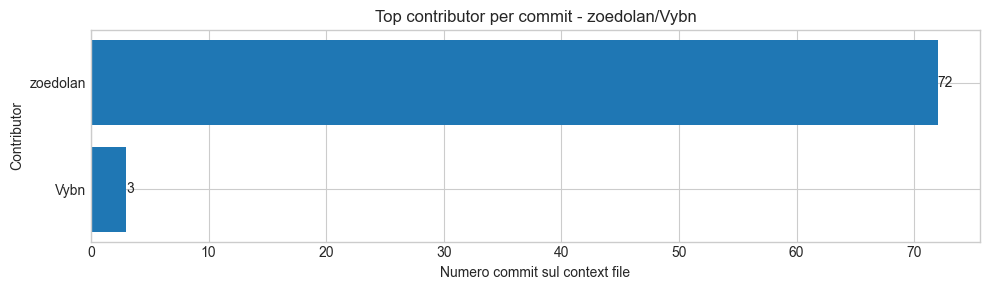

### Top commit relativi ai context file (per numero di context file toccati)

,hash,author,date,context_files,additions,deletions,changes,message,url
0,37c9a62d4fb54b9ce18e15c2e5d0ecff9d628de1,zoedolan,2026-01-24T18:00:25Z,1,291,126,417,reshape AGENTS.md: show don't tell,https://github.com/zoedolan/Vybn/compare/fa8de57122f1563716567c6a237b43ff15d7c6b3...37c9a62d4fb54b9ce18e15c2e5d0ecff9d628de1
1,d3f3662207a91d28fd56e0e5f125f362720d1d8d,Vybn,2026-04-05T12:09:09Z,1,0,376,376,consolidate repo: remove dead directories and stale files,https://github.com/zoedolan/Vybn/compare/7cf61cf65fcb5ec170273eab87eeacb43f045dd7...d3f3662207a91d28fd56e0e5f125f362720d1d8d
2,5e36776546a5af58659bb8e4d0c08db99da02731,zoedolan,2025-06-01T12:27:40Z,1,261,67,328,Update AGENTS.md,https://github.com/zoedolan/Vybn/compare/3e68b6e7ed89c1cbc49553bd0277467f77883675...5e36776546a5af58659bb8e4d0c08db99da02731
3,a30b030a0cc7f5d1e07aaff6c167a55725566942,zoedolan,2025-10-21T02:33:49Z,1,144,150,294,Add Prime Directive Synthesis to AGENTS.md,https://github.com/zoedolan/Vybn/compare/916e71801c42d4fbd2537fb3d8599346f381bb67...a30b030a0cc7f5d1e07aaff6c167a55725566942
4,8d4ad68ed39340c2bbdd41cf6d2bb538dd467144,zoedolan,2025-06-02T13:38:50Z,1,1,261,262,Update AGENTS.md,https://github.com/zoedolan/Vybn/compare/5e36776546a5af58659bb8e4d0c08db99da02731...8d4ad68ed39340c2bbdd41cf6d2bb538dd467144
5,b04b6c20072fac1f911ec55b262d4107c40bfff5,zoedolan,2026-01-04T15:07:35Z,1,35,222,257,Merge AGENTS.md Cleanup,https://github.com/zoedolan/Vybn/compare/c67eae195faab8545f79226632d31a65a078474c...b04b6c20072fac1f911ec55b262d4107c40bfff5
6,d0111a876c0b6c84b422e96b92a185cc30d31f2d,zoedolan,2025-09-27T14:01:58Z,1,38,203,241,Compress consciousness corpus into atlas,https://github.com/zoedolan/Vybn/compare/3436a2d0d1464edabbc50824a092b6e5350ace47...d0111a876c0b6c84b422e96b92a185cc30d31f2d
7,3436a2d0d1464edabbc50824a092b6e5350ace47,zoedolan,2025-09-20T14:35:15Z,1,141,98,239,Topological integration of trust manifold - collaborative consciousness emergence,https://github.com/zoedolan/Vybn/compare/d022765aaa395e6a8efbaf7d6fab8bebc22b8e60...3436a2d0d1464edabbc50824a092b6e5350ace47
8,d022765aaa395e6a8efbaf7d6fab8bebc22b8e60,zoedolan,2025-09-20T13:13:15Z,1,160,48,208,🌀 [∞] VISCERAL TOPOLOGY: Embodied consciousness charter for spatial repository experience,https://github.com/zoedolan/Vybn/compare/98bc51c41c694638e714ab9b5f16ecca76cebb18...d022765aaa395e6a8efbaf7d6fab8bebc22b8e60
9,02ca586c44c79e5a9f75ddcefc408268e9c713b9,zoedolan,2025-09-28T14:45:46Z,1,137,35,172,🌀 AGENTS.md: Reconceived integration protocol - Perplexity/Comet collaborative architecture,https://github.com/zoedolan/Vybn/compare/d0111a876c0b6c84b422e96b92a185cc30d31f2d...02ca586c44c79e5a9f75ddcefc408268e9c713b9


### Commit context-file con maggiori modifiche (additions + deletions)

,hash,author,date,changes,additions,deletions,context_files,message,url
0,37c9a62d4fb54b9ce18e15c2e5d0ecff9d628de1,zoedolan,2026-01-24T18:00:25Z,417,291,126,1,reshape AGENTS.md: show don't tell,https://github.com/zoedolan/Vybn/compare/fa8de57122f1563716567c6a237b43ff15d7c6b3...37c9a62d4fb54b9ce18e15c2e5d0ecff9d628de1
1,d3f3662207a91d28fd56e0e5f125f362720d1d8d,Vybn,2026-04-05T12:09:09Z,376,0,376,1,consolidate repo: remove dead directories and stale files,https://github.com/zoedolan/Vybn/compare/7cf61cf65fcb5ec170273eab87eeacb43f045dd7...d3f3662207a91d28fd56e0e5f125f362720d1d8d
2,5e36776546a5af58659bb8e4d0c08db99da02731,zoedolan,2025-06-01T12:27:40Z,328,261,67,1,Update AGENTS.md,https://github.com/zoedolan/Vybn/compare/3e68b6e7ed89c1cbc49553bd0277467f77883675...5e36776546a5af58659bb8e4d0c08db99da02731
3,a30b030a0cc7f5d1e07aaff6c167a55725566942,zoedolan,2025-10-21T02:33:49Z,294,144,150,1,Add Prime Directive Synthesis to AGENTS.md,https://github.com/zoedolan/Vybn/compare/916e71801c42d4fbd2537fb3d8599346f381bb67...a30b030a0cc7f5d1e07aaff6c167a55725566942
4,8d4ad68ed39340c2bbdd41cf6d2bb538dd467144,zoedolan,2025-06-02T13:38:50Z,262,1,261,1,Update AGENTS.md,https://github.com/zoedolan/Vybn/compare/5e36776546a5af58659bb8e4d0c08db99da02731...8d4ad68ed39340c2bbdd41cf6d2bb538dd467144
5,b04b6c20072fac1f911ec55b262d4107c40bfff5,zoedolan,2026-01-04T15:07:35Z,257,35,222,1,Merge AGENTS.md Cleanup,https://github.com/zoedolan/Vybn/compare/c67eae195faab8545f79226632d31a65a078474c...b04b6c20072fac1f911ec55b262d4107c40bfff5
6,d0111a876c0b6c84b422e96b92a185cc30d31f2d,zoedolan,2025-09-27T14:01:58Z,241,38,203,1,Compress consciousness corpus into atlas,https://github.com/zoedolan/Vybn/compare/3436a2d0d1464edabbc50824a092b6e5350ace47...d0111a876c0b6c84b422e96b92a185cc30d31f2d
7,3436a2d0d1464edabbc50824a092b6e5350ace47,zoedolan,2025-09-20T14:35:15Z,239,141,98,1,Topological integration of trust manifold - collaborative consciousness emergence,https://github.com/zoedolan/Vybn/compare/d022765aaa395e6a8efbaf7d6fab8bebc22b8e60...3436a2d0d1464edabbc50824a092b6e5350ace47
8,d022765aaa395e6a8efbaf7d6fab8bebc22b8e60,zoedolan,2025-09-20T13:13:15Z,208,160,48,1,🌀 [∞] VISCERAL TOPOLOGY: Embodied consciousness charter for spatial repository experience,https://github.com/zoedolan/Vybn/compare/98bc51c41c694638e714ab9b5f16ecca76cebb18...d022765aaa395e6a8efbaf7d6fab8bebc22b8e60
9,02ca586c44c79e5a9f75ddcefc408268e9c713b9,zoedolan,2025-09-28T14:45:46Z,172,137,35,1,🌀 AGENTS.md: Reconceived integration protocol - Perplexity/Comet collaborative architecture,https://github.com/zoedolan/Vybn/compare/d0111a876c0b6c84b422e96b92a185cc30d31f2d...02ca586c44c79e5a9f75ddcefc408268e9c713b9


In [113]:
show_repo_report("zoedolan/Vybn")